In [ ]:
import os, sys
import ast
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import spearmanr
from collections import defaultdict
from glob import glob

sys.path.insert(0, "..")

# ── Config ────────────────────────────────────────────────────────────────────
CSV_PATH = "../results/summary_20251216/all_results.csv"
OUT_DIR  = "../results/plots"

df = pd.read_csv(CSV_PATH)
df["value_list"] = df["value"].apply(ast.literal_eval)
df["last_layer"] = [values[-1] for values in df["value_list"]]

TASKS = [t for t in df["task"].unique()
                if not (t.endswith("_processed_mean") or t.endswith("_processed_noflatten")) and (t.endswith("_mean") or t.endswith("_noflatten"))]
TASKS = ['proeng_thermo_mixed_split_mean',
         'proeng_aav_low_vs_high_mean',
         'proeng_aav_two_vs_many_mean',
         'proeng_aav_one_vs_many_mean',
         'proeng_gb1_low_vs_high_mean',
         'proeng_gb1_two_vs_rest_mean',
         'proeng_gb1_one_vs_rest_mean',
         'annotation_scl_balanced_mean',
         'structure_secondary_structure_tape_ss3_processed_cb513_noflatten',
         'structure_secondary_structure_tape_ss3_processed_ts115_noflatten',
         'structure_secondary_structure_tape_ss3_processed_casp12_noflatten',
         'evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean',
         'evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean',
         'evolution_remote_homology_tape_rh_processed_test-family-holdout_mean',
        ]
METRIC = "test_performance_1"

MODEL_SIZE = {
    "protxlstm_26M_30B":   26,
    "protxlstm_102M_60B": 102,
    "protmamba_28M_30B":   28,
    "protmamba_107M_195B": 107,
    "poet_201M":           201,
}

PROTXLSTM_CKPT_LOSSES = {
    0.125: 2.3195407390594482,
    0.25: 2.2641046047210693,
    0.375: 2.2123701572418213,
    0.5: 2.158830404281616,
    0.625: 2.119004726409912,
    0.75: 2.033418893814087,
    0.875: 1.9276466369628906,
    1: 1.8841066360473633,
}

ARCH_COLOR = {"protxlstm": "#125e74", "protmamba": "#65a568", "poet": "#f5a931"}

MODEL_LABELS = {
    "protxlstm_26M_30B":   "Prot-xLSTM 26M",
    "protxlstm_102M_60B":  "Prot-xLSTM 102M",
    "protmamba_28M_30B":   "ProtMamba 28M",
    "protmamba_107M_195B": "ProtMamba 107M",
    "poet_201M":           "PoET 201M",
}

MODEL_LINESTYLE = {
    "protxlstm_26M_30B":   "--",
    "protxlstm_102M_60B":  "-",
    "protmamba_28M_30B":   "--",
    "protmamba_107M_195B": "-",
    "poet_201M":           "-",
}

MODEL_MARKERSTYLE = {
    "protxlstm_26M_30B":   ".",
    "protxlstm_102M_60B":  "o",
    "protmamba_28M_30B":   ".",
    "protmamba_107M_195B": "o",
    "poet_201M":           "o",
}


MODEL_SIZE_CAT = {
    "protxlstm_26M_30B":   "S",
    "protxlstm_102M_60B":  "L",
    "protmamba_28M_30B":   "S",
    "protmamba_107M_195B": "L",
    "poet_201M":           "L",
}

ARCH_TO_MODEL = {
    "one-hot": "onehot",
    "protxlstm": "protxlstm_102M_60B",
    "protmamba": "protmamba_107M_195B",
    "poet": "poet_201M",
    "carp": "carp_76M",
    "esm": "esm1_t12_85M_UR50S",
    }


MODEL_LAYERS = {
    'esm1_t6_43M_UR50S': 6,
    'esm1_t12_85M_UR50S': 12,
    'esm1b_t33_650M_UR50S': 33,
    'carp_38M': 16,
    'carp_76M': 32,
    'carp_640M': 56,
    'onehot': 0,
    "protxlstm_26M_30B":   16,
    "protxlstm_102M_60B":  16,
    "protmamba_28M_30B":   16,
    "protmamba_107M_195B": 16,
    "poet_201M":           12,
}

TASK_LABELS = {
    'structure_secondary_structure_tape_ss3_processed_casp12_noflatten': "SS3 - CASP12",
    'structure_secondary_structure_tape_ss3_processed_cb513_noflatten': "SS3 - CB513",
    'structure_secondary_structure_tape_ss3_processed_ts115_noflatten': "SS3 - TS115",
    'evolution_remote_homology_tape_rh_processed_test-family-holdout_mean': "RH - Family",
    'evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean': "RH - Superfamily",
    'evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean': "RH - Fold",
    'annotation_scl_balanced_mean': "SCL",
    'proeng_thermo_mixed_split_mean': "Thermostability",
    'proeng_aav_one_vs_many_mean': "AAV - 1 vs. many",
    'proeng_aav_two_vs_many_mean': "AAV - 2 vs. many",
    'proeng_aav_low_vs_high_mean': "AAV - low vs. high",
    'proeng_gb1_one_vs_rest_mean': "GB1 - 1 vs. rest",
    'proeng_gb1_low_vs_high_mean': "GB1 - low vs. high",
    'proeng_gb1_two_vs_rest_mean': "GB1 - 2 vs. rest",
}

TASK_METRIC_LABELS_2 = {
    'structure_secondary_structure_tape_ss3_processed_casp12_noflatten': "Accuracy",
    'structure_secondary_structure_tape_ss3_processed_cb513_noflatten': "Accuracy",
    'structure_secondary_structure_tape_ss3_processed_ts115_noflatten': "Accuracy",
    'evolution_remote_homology_tape_rh_processed_test-family-holdout_mean': "Top-1 Accuracy",
    'evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean': "Top-1 Accuracy",
    'evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean': "Top-1 Accuracy",
    'annotation_scl_balanced_mean': "Accuracy",
    'proeng_thermo_mixed_split_mean': "Spearman ρ",
    'proeng_aav_one_vs_many_mean': "Spearman ρ",
    'proeng_aav_two_vs_many_mean': "Spearman ρ",
    'proeng_aav_low_vs_high_mean': "Spearman ρ",
    'proeng_gb1_one_vs_rest_mean': "Spearman ρ",
    'proeng_gb1_low_vs_high_mean': "Spearman ρ",
    'proeng_gb1_two_vs_rest_mean': "Spearman ρ",
}

TASK_METRIC_LABELS_1 = {
    'structure_secondary_structure_tape_ss3_processed_casp12_noflatten': "AUC",
    'structure_secondary_structure_tape_ss3_processed_cb513_noflatten': "AUC",
    'structure_secondary_structure_tape_ss3_processed_ts115_noflatten': "AUC",
    'evolution_remote_homology_tape_rh_processed_test-family-holdout_mean': "Top-5 Accuracy",
    'evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean': "Top-5 Accuracy",
    'evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean': "Top-5 Accuracy",
    'annotation_scl_balanced_mean': "AUC",
    'proeng_thermo_mixed_split_mean': "NDCG",
    'proeng_aav_one_vs_many_mean': "NDCG",
    'proeng_aav_two_vs_many_mean': "NDCG",
    'proeng_aav_low_vs_high_mean': "NDCG",
    'proeng_gb1_one_vs_rest_mean': "NDCG",
    'proeng_gb1_low_vs_high_mean': "NDCG",
    'proeng_gb1_two_vs_rest_mean': "NDCG",
}

METRIC_LABELS = {
    "test_performance_1": TASK_METRIC_LABELS_1, 
    "test_performance_2": TASK_METRIC_LABELS_2,
}

TASK_INFO = {'annotation_scl_balanced_mean': ('annotation/scl/balanced', 'pytorch', "test"),
         'structure_secondary_structure_tape_ss3_processed_casp12_noflatten': ('structure/secondary_structure/tape_ss3_processed', 'pytorch', "casp12"),
         'structure_secondary_structure_tape_ss3_processed_cb513_noflatten': ('structure/secondary_structure/tape_ss3_processed', 'pytorch', "cb513"),
         'structure_secondary_structure_tape_ss3_processed_ts115_noflatten': ('structure/secondary_structure/tape_ss3_processed', 'pytorch', "ts115"),
         'proeng_gb1_one_vs_rest_mean': ('proeng/gb1/one_vs_rest', 'sklearn', "test"),
         'proeng_gb1_low_vs_high_mean': ('proeng/gb1/low_vs_high', 'sklearn', "test"),
         'proeng_gb1_two_vs_rest_mean': ('proeng/gb1/two_vs_rest', 'sklearn', "test"),
         'proeng_aav_low_vs_high_mean': ('proeng/aav/low_vs_high', 'sklearn', "test"),
         'proeng_aav_two_vs_many_mean': ('proeng/aav/two_vs_many', 'sklearn', "test"),
         'proeng_aav_one_vs_many_mean': ('proeng/aav/one_vs_many', 'sklearn', "test"),
         'proeng_thermo_mixed_split_mean': ('proeng/thermo/mixed_split', 'sklearn', "test"),
         'evolution_remote_homology_tape_rh_processed_test-family-holdout_mean': ('evolution/remote_homology/tape_rh_processed', 'pytorch', "test_family_holdout"),
         'evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean': ('evolution/remote_homology/tape_rh_processed', 'pytorch', "test_superfamily_holdout"),
         'evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean': ('evolution/remote_homology/tape_rh_processed', 'pytorch', "test_fold_holdout"),
         }

def _rows(df, model, task, metric, ptp=1.0, seq_num=200, ablation="emb"):
    return df[
        (df["model"]       == model)    &
        (df["ablation"]    == ablation) &
        (df["ptp"]         == ptp)      &
        (df["max_seq_num"] == seq_num)  &
        (df["task"]        == task)     &
        (df["metric"]      == metric)
    ]

def avg_last_layer(sub):
    """Mean ± std across seeds; returns (mean_number, std_number)."""
    arrays = np.array(sub["last_layer"].tolist())
    return arrays.mean(0), arrays.std(0)

def avg_layers(sub):
    """Mean ± std across seeds; returns (mean_array, std_array)."""
    arrays = np.array(sub["value_list"].tolist())
    return arrays.mean(0), arrays.std(0)    

def best_layer(sub, obj="max"):
    """Scalar: max over layers after averaging across seeds."""
    mean, std = avg_layers(sub)
    if obj == "max":
        idx = mean.argmax()
    elif obj == "min":
        idx = mean.argmin()
    return (mean[idx], std[idx]), idx

def get_onehot(task: str, metric):
    subfolder, eval_framework, test_split = TASK_INFO[task]
    ROOT = "../results"
    agg = "noflatten" if "structure" in subfolder else "flatten"
    p = os.path.join(ROOT, f"{eval_framework}-onehot/seed-42", subfolder, "onehot", agg, f"onehot-{agg}-layer_0.pkl")
    df_ = pd.read_pickle(p)

    if eval_framework == "pytorch":
        if metric == "test_performance_1":
            test_metric = "top5_acc" if "evolution" in subfolder else "rocauc"
        else:
            test_metric = "acc"
    else:
        test_metric = 'ndcg' if metric == "test_performance_1" else "rho"

    perf = df_[test_split][test_metric]
    return perf if test_metric != "rho" else perf[0]

def perform_t_test(
    grouped_df,
    target_value: float,
    test_col: str = "last_layer",
    sig_cutoff: float = 0.05,
):
    t_statistic, one_tailed_p_value = stats.ttest_1samp(
        grouped_df[test_col], target_value, alternative="less"
    )
    return pd.Series(
        {
            "mean": grouped_df[test_col].mean(),
            "std": grouped_df[test_col].std(),
            "n": len(grouped_df[test_col]),
            "t_statistic": t_statistic,
            "p_value": one_tailed_p_value,
            "significant": one_tailed_p_value < sig_cutoff,
        }
    )

def get_ablation_results(df, model, task, ablation, metric):
    abl_df = _rows(df, model, task, ptp=0.0, seq_num=200, ablation=ablation, metric=metric)
    ref_df = _rows(df, model, task, ptp=1.0, seq_num=200, ablation="emb", metric=metric)

    assert set(ref_df["sampleseed"]) == set(abl_df["sampleseed"]), "Ablation and reference do not have same sampleseeds"
    sampleseeds = ref_df["sampleseed"]

    results = []

    for seed in sampleseeds:
        sub_abl_df = abl_df[abl_df["sampleseed"] == seed]
        sub_ref_df = ref_df[ref_df["sampleseed"] == seed]
        assert len(sub_ref_df) == 1, f"ref_df contains multiple values for {seed}"

        results.append(perform_t_test(
            sub_abl_df,
            sub_ref_df["last_layer"],
            test_col="last_layer",
            sig_cutoff=0.05,
        ))

    return pd.DataFrame(results, index=sampleseeds)

def gradient_line(
    ax,
    x,
    y,
    color="C0",
    alpha_start=0.2,
    alpha_end=1.0,
    linewidth=2,
    linestyle="solid",
    **kwargs,
):
    """
    Draw a line whose alpha increases along the x-direction.

    Parameters
    ----------
    ax : matplotlib axis
    x, y : array-like
        Coordinates of the line.
    color : matplotlib color
        Base color of the line.
    alpha_start : float
        Alpha at the beginning of the line.
    alpha_end : float
        Alpha at the end of the line.
    linewidth : float
        Width of the line.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    # create line segments
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # generate alpha gradient
    alphas = np.linspace(alpha_start, alpha_end, len(segments))

    # convert color to RGBA
    from matplotlib.colors import to_rgba
    r, g, b, _ = to_rgba(color)

    colors = [(r, g, b, a) for a in alphas]

    lc = LineCollection(segments, colors=colors, linewidth=linewidth, linestyle=linestyle, **kwargs)
    ax.add_collection(lc)

    # update limits so matplotlib doesn't ignore the collection
    ax.autoscale()

    return lc

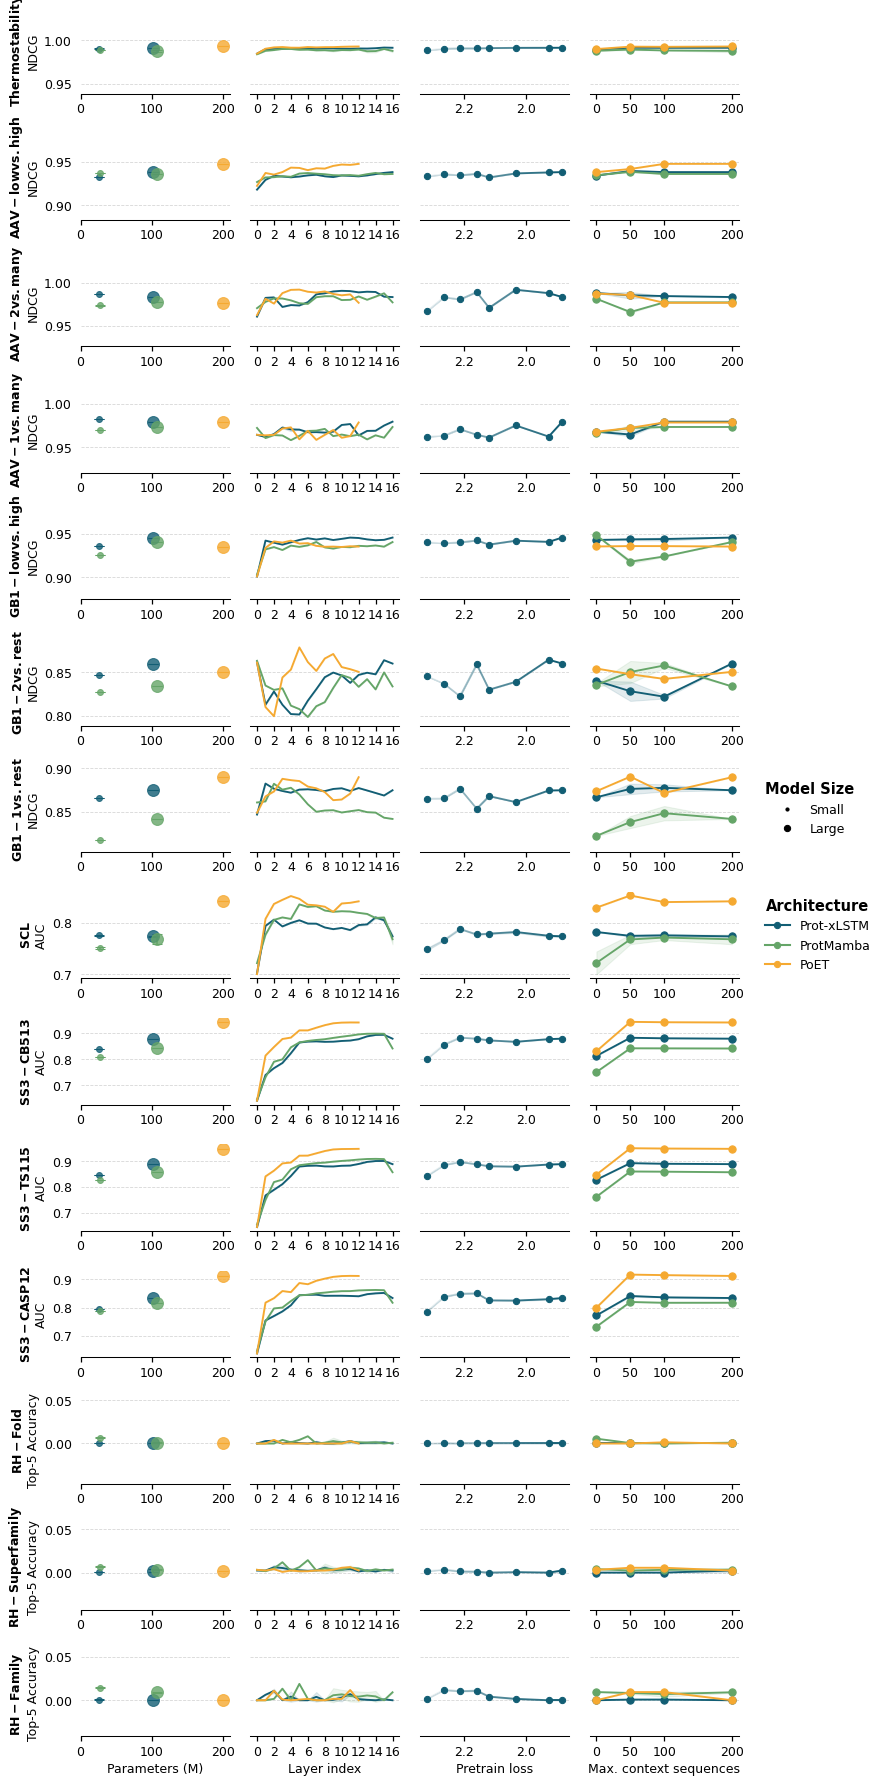

In [12]:
GLOBAL_STYLE = {
    # Figure
    "figure.figsize": (12, 24),
    "figure.dpi": 75,

    # Fonts
    "font.size": 14,
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # Axes
    "axes.linewidth": 1,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,

    # Grid
    "grid.linestyle": "--",
    "grid.alpha": 0.5, # 0.7

    # Ticks
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "ytick.left": False,

    # Error bars
    "errorbar.capsize": 5,

    # Bars / patches
    "patch.edgecolor": "black",
    "patch.linewidth": 1.0,
    "patch.force_edgecolor": False, 

    # Legend
    "legend.fontsize": 12,        
    "legend.title_fontsize": 14,  

    # Savefig
    "savefig.bbox": "tight",

    "hatch.linewidth": 1.5,
}

mpl.rcParams.update(GLOBAL_STYLE)

# ── Figure ────────────────────────────────────────────────────────────────────
nrows = len(TASKS)
fig, axs = plt.subplots(nrows, 4, sharey='row')

color_legend = [
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protxlstm"], lw=2, label="Prot-xLSTM"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protmamba"], lw=2, label="ProtMamba"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["poet"], lw=2, label="PoET"),
]

marker_legend = [
    Line2D([0], [0], marker=".", color="black", linestyle="", label="Small"),
    Line2D([0], [0], marker="o", color="black", linestyle="", label="Large"),
]

for row, task in enumerate(TASKS):
    first_row = row == 0
    last_row = row == nrows-1

    if row == nrows:
        break

    # ── (A) Model-size scaling ────────────────────────────────────────────────────
    ax = axs[0] if nrows == 1 else axs[row, 0]
    plotted_archs = set()
    for model, label in MODEL_LABELS.items():
        arch  = model.split("_")[0]
        color = ARCH_COLOR[arch]
        sub   = _rows(df, model, task, metric=METRIC)
        if sub.empty:
            continue
        mean, std = avg_last_layer(sub)
        size = MODEL_SIZE[model]
        marker = MODEL_MARKERSTYLE[model]
        ax.errorbar(size, mean, yerr=std, color=color)
        ax.scatter(size, mean, color=color, s=130, zorder=3, alpha=0.8, 
                   linestyle='None', marker=marker,
                   label=arch if arch not in plotted_archs else "_nolegend_")
        plotted_archs.add(arch)

    # ax.set_xscale("log")
    if last_row:
        ax.set_xlabel("Parameters (M)")
    ax.set_xlim(0)

    # ax.legend(title="Architecture", frameon=False, loc="center left", bbox_to_anchor=(1, 0.5))
    
    # if first_row:
        
    #     ax.set_title("Model-size")
    

    ax.set_ylabel(f"$\\mathbf{{{TASK_LABELS[task]}}}$\n{METRIC_LABELS[METRIC][task]}")

    # ── (B) Layer-wise scaling ────────────────────────────────────────────────────
    ax = axs[1] if nrows == 1 else axs[row, 1]
    for model, label in MODEL_LABELS.items():
        if MODEL_SIZE_CAT[model] == "L":
            color = ARCH_COLOR[model.split("_")[0]]
            ls    = MODEL_LINESTYLE[model]
            sub   = _rows(df, model, task, metric=METRIC)
            if sub.empty:
                continue
            mean, std = avg_layers(sub)
            x = np.arange(len(mean))
            ax.plot(x, mean, label=label, color=color, linestyle=ls, linewidth=1.8)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)
    
    if last_row:
        ax.set_xlabel("Layer index")
    # if first_row:
    #     ax.set_title("Layer-wise")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # ── (C) Pre-training performance scaling ──────────────────────────────────────
    ax = axs[2]  if nrows == 1 else axs[row, 2]
    model = "protxlstm_102M_60B"
    color = ARCH_COLOR["protxlstm"]
    xs, ys, yerrs = [], [], []
    for ptp, loss in sorted(PROTXLSTM_CKPT_LOSSES.items()):
        sub = _rows(df, model, task, ptp=ptp, metric=METRIC)
        if sub.empty:
            continue
        xs.append(loss)

        mean, std = avg_last_layer(sub)
        ys.append(mean)
        yerrs.append(std)

    gradient_line(ax, xs, ys, color=color, alpha_start=0.1, alpha_end=1.0, linewidth=1.8)
    # for xi, yi, a in zip(xs, ys, np.linspace(0.1, 1.0, len(x))): # linestyle="o-", label="Prot-xLSTM 102M", markersize=7
    ax.scatter(xs, ys, marker="o", color=color)#, s=7)

    # ax.plot(xs, ys, "o-", label="Prot-xLSTM 102M", color=color, markersize=7, linewidth=1.8)
    ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

    ax.invert_xaxis() 

    if last_row:
        ax.set_xlabel("Pretrain loss")
    # if first_row:
    #     ax.set_title("Pre-training loss")

    # ── (D) Context-length scaling ────────────────────────────────────────────────
    ax = axs[3]  if nrows == 1 else axs[row, 3]
    ctx_models  = ["protxlstm_102M_60B", "protmamba_107M_195B", "poet_201M"]
    all_seq_nums = sorted(df["max_seq_num"].unique())

    for model in ctx_models:
        arch  = model.split("_")[0]
        color = ARCH_COLOR[arch]
        label = MODEL_LABELS[model]

        xs, ys, yerrs = [], [], []
        for seq_num in all_seq_nums:
            sub = _rows(df, model, task, seq_num=seq_num, metric=METRIC)
            if sub.empty:
                continue
            xs.append(seq_num)

            mean, std = avg_last_layer(sub)
            ys.append(mean)
            yerrs.append(std)
        if len(xs) > 1:
            ax.plot(xs, ys, "o-", color=color, label=label, linewidth=1.8, markersize=7)
            ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

    ax.set_xticks(all_seq_nums)
    if last_row:
        ax.set_xlabel("Max. context sequences")
    # if first_row:
    #     ax.set_title("Context-length")
    if row+1 == 7:
        ax.legend(handles=marker_legend, title="Model Size", title_fontproperties={'weight': 'bold'}, frameon=False, loc="center left", bbox_to_anchor=(1.1, 0.5))
    if row+1 == 8:
        ax.legend(handles=color_legend, title="Architecture", title_fontproperties={'weight': 'bold'}, frameon=False,  loc="center left", bbox_to_anchor=(1.1, 0.5))

    ymin, ymax = ax.get_ylim()
    # ax.set_ylim(bottom=max(0, ymin))

    min_range = 0.1
    current_range = ymax - ymin

    if current_range < min_range:
        center = (ymin + ymax) / 2
        # if center - min_range/2 < 0:
        #     ax.set_ylim(0, center + min_range)
        # else:
        ax.set_ylim(center - min_range/2, center + min_range/2)

fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"scaling_overview-{METRIC}{ext}"),
                bbox_inches="tight", dpi=150)

plt.show()

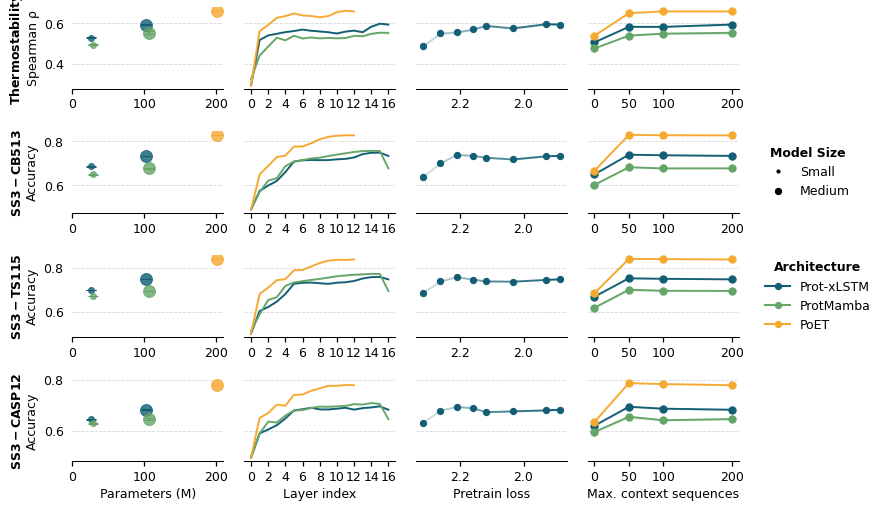

In [3]:
# ── Figure ────────────────────────────────────────────────────────────────────
nrows = 4
fig, axs = plt.subplots(nrows, 4, sharey='row', figsize=(12,7))
color_legend = [
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protxlstm"], lw=2, label="Prot-xLSTM"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protmamba"], lw=2, label="ProtMamba"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["poet"], lw=2, label="PoET"),
]

marker_legend = [
    Line2D([0], [0], marker=".", color="black", linestyle="", label="Small"),
    Line2D([0], [0], marker="o", color="black", linestyle="", label="Medium"),
]

task_subset = [
    "proeng_thermo_mixed_split_mean",
    'structure_secondary_structure_tape_ss3_processed_cb513_noflatten',
    'structure_secondary_structure_tape_ss3_processed_ts115_noflatten',
    'structure_secondary_structure_tape_ss3_processed_casp12_noflatten',
]

for row, task in enumerate(task_subset):
    first_row = row == 0
    last_row = row == nrows-1

    if row == nrows:
        break

    # ── (A) Model-size scaling ────────────────────────────────────────────────────
    ax = axs[0] if nrows == 1 else axs[row, 0]
    plotted_archs = set()
    for model, label in MODEL_LABELS.items():
        arch  = model.split("_")[0]
        color = ARCH_COLOR[arch]
        sub   = _rows(df, model, task, metric=METRIC)
        if sub.empty:
            continue
        mean, std = avg_last_layer(sub)
        size = MODEL_SIZE[model]
        marker = MODEL_MARKERSTYLE[model]
        ax.errorbar(size, mean, yerr=std, color=color)
        ax.scatter(size, mean, color=color, s=130, zorder=3, alpha=0.8, 
                   linestyle='None', marker=marker,
                   label=arch if arch not in plotted_archs else "_nolegend_")
        plotted_archs.add(arch)

    # ax.set_xscale("log")
    if last_row:
        ax.set_xlabel("Parameters (M)")
    ax.set_xlim(0)

    # ax.legend(title="Architecture", frameon=False, loc="center left", bbox_to_anchor=(1, 0.5))
    
    # if first_row:
    #     ax.set_title("a",  fontsize=18, loc="left")
    

    ax.set_ylabel(f"$\\mathbf{{{TASK_LABELS[task]}}}$\n{METRIC_LABELS[METRIC][task]}")

    # ── (B) Layer-wise scaling ────────────────────────────────────────────────────
    ax = axs[1] if nrows == 1 else axs[row, 1]
    for model, label in MODEL_LABELS.items():
        if MODEL_SIZE_CAT[model] == "L":
            color = ARCH_COLOR[model.split("_")[0]]
            ls    = MODEL_LINESTYLE[model]
            sub   = _rows(df, model, task, metric=METRIC)
            if sub.empty:
                continue
            mean, std = avg_layers(sub)
            x = np.arange(len(mean))
            ax.plot(x, mean, label=label, color=color, linestyle=ls, linewidth=1.8)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)
    
    if last_row:
        ax.set_xlabel("Layer index")
    # if first_row:
    #     ax.set_title("b",  fontsize=18, loc="left")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # ── (C) Pre-training performance scaling ──────────────────────────────────────
    ax = axs[2]  if nrows == 1 else axs[row, 2]
    model = "protxlstm_102M_60B"
    color = ARCH_COLOR["protxlstm"]
    xs, ys, yerrs = [], [], []
    for ptp, loss in sorted(PROTXLSTM_CKPT_LOSSES.items()):
        sub = _rows(df, model, task, ptp=ptp, metric=METRIC)
        if sub.empty:
            continue
        xs.append(loss)

        mean, std = avg_last_layer(sub)
        ys.append(mean)
        yerrs.append(std)

    gradient_line(ax, xs, ys, color=color, alpha_start=0.1, alpha_end=1.0, linewidth=1.8)
    # for xi, yi, a in zip(xs, ys, np.linspace(0.1, 1.0, len(x))): # linestyle="o-", label="Prot-xLSTM 102M", markersize=7
    ax.scatter(xs, ys, marker="o", color=color)#, s=7)

    # ax.plot(xs, ys, "o-", label="Prot-xLSTM 102M", color=color, markersize=7, linewidth=1.8)
    ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

    ax.invert_xaxis() 

    if last_row:
        ax.set_xlabel("Pretrain loss")
    # if first_row:
    #     ax.set_title("c",  fontsize=18, loc="left")

    # ── (D) Context-length scaling ────────────────────────────────────────────────
    ax = axs[3]  if nrows == 1 else axs[row, 3]
    ctx_models  = ["protxlstm_102M_60B", "protmamba_107M_195B", "poet_201M"]
    all_seq_nums = sorted(df["max_seq_num"].unique())

    for model in ctx_models:
        arch  = model.split("_")[0]
        color = ARCH_COLOR[arch]
        label = MODEL_LABELS[model]

        xs, ys, yerrs = [], [], []
        for seq_num in all_seq_nums:
            sub = _rows(df, model, task, seq_num=seq_num, metric=METRIC)
            if sub.empty:
                continue
            xs.append(seq_num)

            mean, std = avg_last_layer(sub)
            ys.append(mean)
            yerrs.append(std)
        if len(xs) > 1:
            ax.plot(xs, ys, "o-", color=color, label=label, linewidth=1.8, markersize=7)
            ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

    ax.set_xticks(all_seq_nums)
    if last_row:
        ax.set_xlabel("Max. context sequences")
    # if first_row:
    #     ax.set_title("d",  fontsize=18, loc="left")
    if row+1 == 2:
        ax.legend(handles=marker_legend, title="Model Size", title_fontproperties={'weight': 'bold','size': 12}, frameon=False, loc="center left", bbox_to_anchor=(1.1, 0.5))
    if row+1 == 3:
        ax.legend(handles=color_legend, title="Architecture", title_fontproperties={'weight': 'bold','size': 12}, frameon=False, loc="center left", bbox_to_anchor=(1.1, 0.5))

    ymin, ymax = ax.get_ylim()
    # ax.set_ylim(bottom=max(0, ymin))

    min_range = 0.1
    current_range = ymax - ymin

    if current_range < min_range:
        center = (ymin + ymax) / 2
        # if center - min_range/2 < 0:
        #     ax.set_ylim(0, center + min_range)
        # else:
        ax.set_ylim(center - min_range/2, center + min_range/2)

fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"scaling_nearalignment-{METRIC}{ext}"),
                bbox_inches="tight", dpi=150)

plt.show()

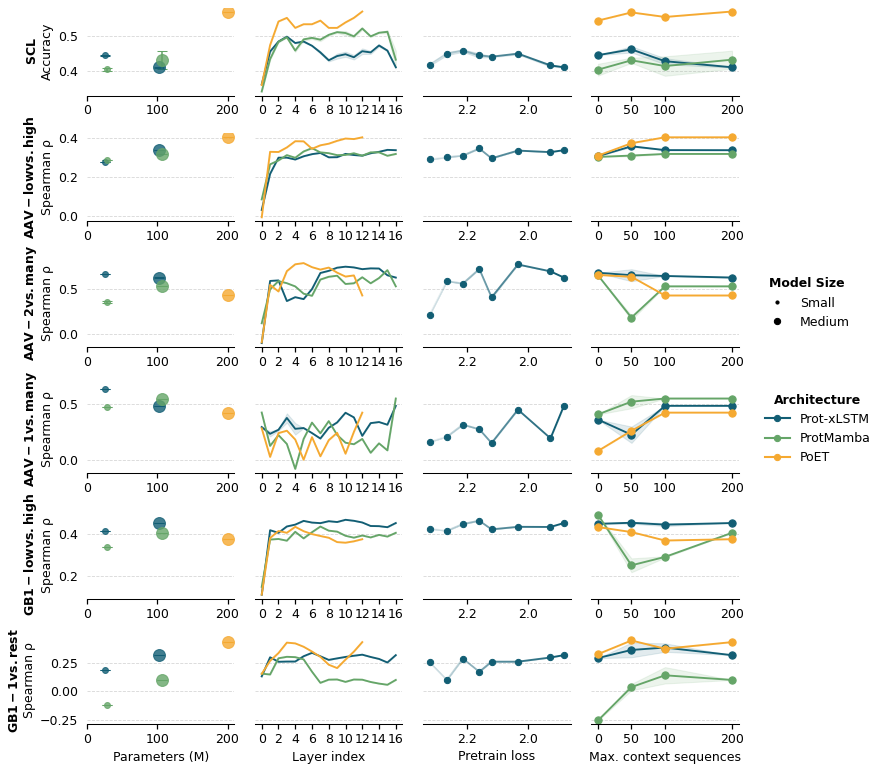

In [4]:
# ── Figure ────────────────────────────────────────────────────────────────────
nrows = 6
fig, axs = plt.subplots(nrows, 4, sharey='row', figsize=(12,10.5))
color_legend = [
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protxlstm"], lw=2, label="Prot-xLSTM"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protmamba"], lw=2, label="ProtMamba"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["poet"], lw=2, label="PoET"),
]

marker_legend = [
    Line2D([0], [0], marker=".", color="black", linestyle="", label="Small"),
    Line2D([0], [0], marker="o", color="black", linestyle="", label="Medium"),
]

task_subset = [
    "annotation_scl_balanced_mean",
    'proeng_aav_low_vs_high_mean',
    "proeng_aav_two_vs_many_mean",
    "proeng_aav_one_vs_many_mean",
    'proeng_gb1_low_vs_high_mean',
    "proeng_gb1_one_vs_rest_mean",
]

for row, task in enumerate(task_subset):
    first_row = row == 0
    last_row = row == nrows-1

    if row == nrows:
        break

    # ── (A) Model-size scaling ────────────────────────────────────────────────────
    ax = axs[0] if nrows == 1 else axs[row, 0]
    plotted_archs = set()
    for model, label in MODEL_LABELS.items():
        arch  = model.split("_")[0]
        color = ARCH_COLOR[arch]
        sub   = _rows(df, model, task, metric=METRIC)
        if sub.empty:
            continue
        mean, std = avg_last_layer(sub)
        size = MODEL_SIZE[model]
        marker = MODEL_MARKERSTYLE[model]
        ax.errorbar(size, mean, yerr=std, color=color)
        ax.scatter(size, mean, color=color, s=130, zorder=3, alpha=0.8, 
                   linestyle='None', marker=marker,
                   label=arch if arch not in plotted_archs else "_nolegend_")
        plotted_archs.add(arch)

    # ax.set_xscale("log")
    if last_row:
        ax.set_xlabel("Parameters (M)")
    ax.set_xlim(0)

    # ax.legend(title="Architecture", frameon=False, loc="center left", bbox_to_anchor=(1, 0.5))
    
    # if first_row:
    #     ax.set_title("a",  fontsize=18, loc="left")
    

    ax.set_ylabel(f"$\\mathbf{{{TASK_LABELS[task]}}}$\n{METRIC_LABELS[METRIC][task]}")

    # ── (B) Layer-wise scaling ────────────────────────────────────────────────────
    ax = axs[1] if nrows == 1 else axs[row, 1]
    for model, label in MODEL_LABELS.items():
        if MODEL_SIZE_CAT[model] == "L":
            color = ARCH_COLOR[model.split("_")[0]]
            ls    = MODEL_LINESTYLE[model]
            sub   = _rows(df, model, task, metric=METRIC)
            if sub.empty:
                continue
            mean, std = avg_layers(sub)
            x = np.arange(len(mean))
            ax.plot(x, mean, label=label, color=color, linestyle=ls, linewidth=1.8)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)
    
    if last_row:
        ax.set_xlabel("Layer index")
    # if first_row:
    #     ax.set_title("b",  fontsize=18, loc="left")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # ── (C) Pre-training performance scaling ──────────────────────────────────────
    ax = axs[2]  if nrows == 1 else axs[row, 2]
    model = "protxlstm_102M_60B"
    color = ARCH_COLOR["protxlstm"]
    xs, ys, yerrs = [], [], []
    for ptp, loss in sorted(PROTXLSTM_CKPT_LOSSES.items()):
        sub = _rows(df, model, task, ptp=ptp, metric=METRIC)
        if sub.empty:
            continue
        xs.append(loss)

        mean, std = avg_last_layer(sub)
        ys.append(mean)
        yerrs.append(std)

    gradient_line(ax, xs, ys, color=color, alpha_start=0.1, alpha_end=1.0, linewidth=1.8)
    # for xi, yi, a in zip(xs, ys, np.linspace(0.1, 1.0, len(x))): # linestyle="o-", label="Prot-xLSTM 102M", markersize=7
    ax.scatter(xs, ys, marker="o", color=color)#, s=7)

    # ax.plot(xs, ys, "o-", label="Prot-xLSTM 102M", color=color, markersize=7, linewidth=1.8)
    ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

    ax.invert_xaxis() 

    if last_row:
        ax.set_xlabel("Pretrain loss")
    # if first_row:
    #     ax.set_title("c",  fontsize=18, loc="left")

    # ── (D) Context-length scaling ────────────────────────────────────────────────
    ax = axs[3]  if nrows == 1 else axs[row, 3]
    ctx_models  = ["protxlstm_102M_60B", "protmamba_107M_195B", "poet_201M"]
    all_seq_nums = sorted(df["max_seq_num"].unique())

    for model in ctx_models:
        arch  = model.split("_")[0]
        color = ARCH_COLOR[arch]
        label = MODEL_LABELS[model]

        xs, ys, yerrs = [], [], []
        for seq_num in all_seq_nums:
            sub = _rows(df, model, task, seq_num=seq_num, metric=METRIC)
            if sub.empty:
                continue
            xs.append(seq_num)

            mean, std = avg_last_layer(sub)
            ys.append(mean)
            yerrs.append(std)
        if len(xs) > 1:
            ax.plot(xs, ys, "o-", color=color, label=label, linewidth=1.8, markersize=7)
            ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

    ax.set_xticks(all_seq_nums)
    if last_row:
        ax.set_xlabel("Max. context sequences")
    # if first_row:
    #     ax.set_title("d",  fontsize=18, loc="left")
    if row+1 == 3:
        ax.legend(handles=marker_legend, title="Model Size", title_fontproperties={'weight': 'bold','size': 12}, frameon=False, loc="center left", bbox_to_anchor=(1.1, 0.5))
    if row+1 == 4:
        ax.legend(handles=color_legend, title="Architecture", title_fontproperties={'weight': 'bold','size': 12}, frameon=False, loc="center left", bbox_to_anchor=(1.1, 0.5))

    ymin, ymax = ax.get_ylim()
    # ax.set_ylim(bottom=max(0, ymin))

    min_range = 0.1
    current_range = ymax - ymin

    if current_range < min_range:
        center = (ymin + ymax) / 2
        # if center - min_range/2 < 0:
        #     ax.set_ylim(0, center + min_range)
        # else:
        ax.set_ylim(center - min_range/2, center + min_range/2)

fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"scaling_lowlevel-{METRIC}{ext}"),
                bbox_inches="tight", dpi=150)

plt.show()

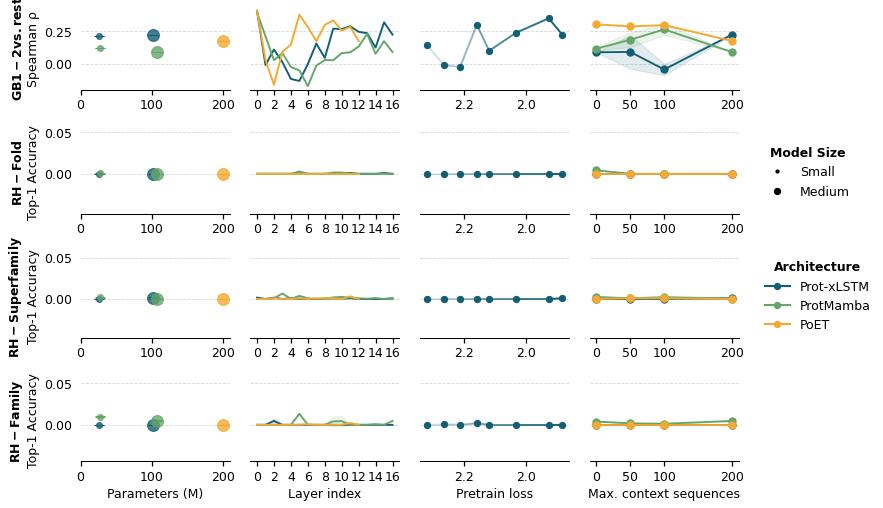

In [5]:
# ── Figure ────────────────────────────────────────────────────────────────────
nrows = 4
fig, axs = plt.subplots(nrows, 4, sharey='row', figsize=(12,7))
color_legend = [
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protxlstm"], lw=2, label="Prot-xLSTM"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protmamba"], lw=2, label="ProtMamba"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["poet"], lw=2, label="PoET"),
]

marker_legend = [
    Line2D([0], [0], marker=".", color="black", linestyle="", label="Small"),
    Line2D([0], [0], marker="o", color="black", linestyle="", label="Medium"),
]

task_subset = [
    # "proeng_aav_one_vs_many_mean",
    "proeng_gb1_two_vs_rest_mean",
 'evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean',
 'evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean',
 'evolution_remote_homology_tape_rh_processed_test-family-holdout_mean']

for row, task in enumerate(task_subset):
    first_row = row == 0
    last_row = row == nrows-1

    if row == nrows:
        break

    # ── (A) Model-size scaling ────────────────────────────────────────────────────
    ax = axs[0] if nrows == 1 else axs[row, 0]
    plotted_archs = set()
    for model, label in MODEL_LABELS.items():
        arch  = model.split("_")[0]
        color = ARCH_COLOR[arch]
        sub   = _rows(df, model, task, metric=METRIC)
        if sub.empty:
            continue
        mean, std = avg_last_layer(sub)
        size = MODEL_SIZE[model]
        marker = MODEL_MARKERSTYLE[model]
        ax.errorbar(size, mean, yerr=std, color=color)
        ax.scatter(size, mean, color=color, s=130, zorder=3, alpha=0.8, 
                   linestyle='None', marker=marker,
                   label=arch if arch not in plotted_archs else "_nolegend_")
        plotted_archs.add(arch)

    # ax.set_xscale("log")
    if last_row:
        ax.set_xlabel("Parameters (M)")
    ax.set_xlim(0)

    # ax.legend(title="Architecture", frameon=False, loc="center left", bbox_to_anchor=(1, 0.5))
    
    # if first_row:
    #     ax.set_title("a",  fontsize=18, loc="left")
    

    ax.set_ylabel(f"$\\mathbf{{{TASK_LABELS[task]}}}$\n{METRIC_LABELS[METRIC][task]}")

    # ── (B) Layer-wise scaling ────────────────────────────────────────────────────
    ax = axs[1] if nrows == 1 else axs[row, 1]
    for model, label in MODEL_LABELS.items():
        if MODEL_SIZE_CAT[model] == "L":
            color = ARCH_COLOR[model.split("_")[0]]
            ls    = MODEL_LINESTYLE[model]
            sub   = _rows(df, model, task, metric=METRIC)
            if sub.empty:
                continue
            mean, std = avg_layers(sub)
            x = np.arange(len(mean))
            ax.plot(x, mean, label=label, color=color, linestyle=ls, linewidth=1.8)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)
    
    if last_row:
        ax.set_xlabel("Layer index")
    # if first_row:
    #     ax.set_title("b",  fontsize=18, loc="left")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # ── (C) Pre-training performance scaling ──────────────────────────────────────
    ax = axs[2]  if nrows == 1 else axs[row, 2]
    model = "protxlstm_102M_60B"
    color = ARCH_COLOR["protxlstm"]
    xs, ys, yerrs = [], [], []
    for ptp, loss in sorted(PROTXLSTM_CKPT_LOSSES.items()):
        sub = _rows(df, model, task, ptp=ptp, metric=METRIC)
        if sub.empty:
            continue
        xs.append(loss)

        mean, std = avg_last_layer(sub)
        ys.append(mean)
        yerrs.append(std)

    gradient_line(ax, xs, ys, color=color, alpha_start=0.1, alpha_end=1.0, linewidth=1.8)
    # for xi, yi, a in zip(xs, ys, np.linspace(0.1, 1.0, len(x))): # linestyle="o-", label="Prot-xLSTM 102M", markersize=7
    ax.scatter(xs, ys, marker="o", color=color)#, s=7)

    # ax.plot(xs, ys, "o-", label="Prot-xLSTM 102M", color=color, markersize=7, linewidth=1.8)
    ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

    ax.invert_xaxis() 

    if last_row:
        ax.set_xlabel("Pretrain loss")
    # if first_row:
    #     ax.set_title("c",  fontsize=18, loc="left")

    # ── (D) Context-length scaling ────────────────────────────────────────────────
    ax = axs[3]  if nrows == 1 else axs[row, 3]
    ctx_models  = ["protxlstm_102M_60B", "protmamba_107M_195B", "poet_201M"]
    all_seq_nums = sorted(df["max_seq_num"].unique())

    for model in ctx_models:
        arch  = model.split("_")[0]
        color = ARCH_COLOR[arch]
        label = MODEL_LABELS[model]

        xs, ys, yerrs = [], [], []
        for seq_num in all_seq_nums:
            sub = _rows(df, model, task, seq_num=seq_num, metric=METRIC)
            if sub.empty:
                continue
            xs.append(seq_num)

            mean, std = avg_last_layer(sub)
            ys.append(mean)
            yerrs.append(std)
        if len(xs) > 1:
            ax.plot(xs, ys, "o-", color=color, label=label, linewidth=1.8, markersize=7)
            ax.fill_between(xs, np.array(ys) - np.array(yerrs), np.array(ys) + np.array(yerrs), color=color, alpha=0.12)

    ax.set_xticks(all_seq_nums)
    if last_row:
        ax.set_xlabel("Max. context sequences")
    # if first_row:
    #     ax.set_title("d",  fontsize=18, loc="left")
    if row+1 == 2:
        ax.legend(handles=marker_legend, title="Model Size", title_fontproperties={'weight': 'bold','size': 12}, frameon=False, loc="center left", bbox_to_anchor=(1.1, 0.5))
    if row+1 == 3:
        ax.legend(handles=color_legend, title="Architecture", title_fontproperties={'weight': 'bold','size': 12}, frameon=False, loc="center left", bbox_to_anchor=(1.1, 0.5))

    ymin, ymax = ax.get_ylim()
    # ax.set_ylim(bottom=max(0, ymin))

    min_range = 0.1
    current_range = ymax - ymin

    if current_range < min_range:
        center = (ymin + ymax) / 2
        # if center - min_range/2 < 0:
        #     ax.set_ylim(0, center + min_range)
        # else:
        ax.set_ylim(center - min_range/2, center + min_range/2)

fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"scaling_noalignment-{METRIC}{ext}"),
                bbox_inches="tight", dpi=150)

plt.show()

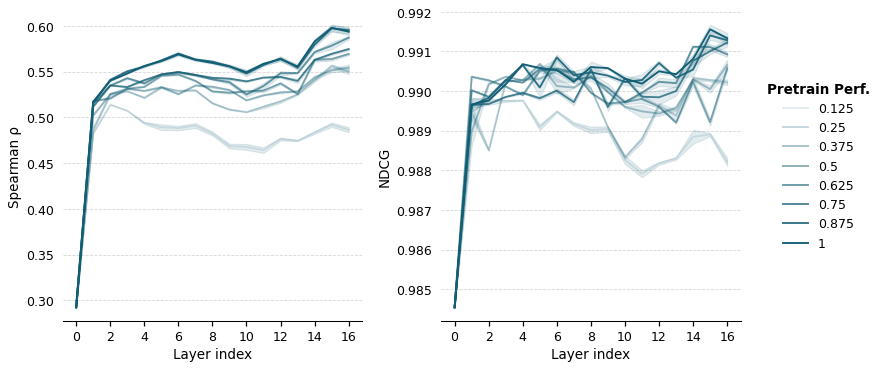

In [18]:
# ── Figure ────────────────────────────────────────────────────────────────────
tasks = [TASKS[0]]
nrows = len(tasks)
fig, axs = plt.subplots(nrows, 2, figsize=(12,5.15))

color_legend = [
    Line2D([0], [0], marker="o", color="#5C1A3A", lw=2, label="Prot-xLSTM"),
    Line2D([0], [0], marker="o", color="#5E8560", lw=2, label="ProtMamba"),
    Line2D([0], [0], marker="o", color="#DDAA33", lw=2, label="PoET"),
]

marker_legend = [
    Line2D([0], [0], marker=".", color="black", linestyle="", label="Small"),
    Line2D([0], [0], marker="o", color="black", linestyle="", label="Large"),
]

for m, metric in enumerate(["test_performance_2", "test_performance_1"]):
    for row, task in enumerate(tasks):
        first_row = row == 0
        last_row = row == nrows-1

        if row == nrows:
            break

        # ── (B) Layer-wise scaling ────────────────────────────────────────────────────
        ax = axs[m]
        model = "protxlstm_102M_60B"
        color = ARCH_COLOR["protxlstm"]
        for ptp, loss in sorted(PROTXLSTM_CKPT_LOSSES.items()):
            mean, std = avg_last_layer(sub)
            ys.append(mean)
            yerrs.append(std)
        
            ls  = MODEL_LINESTYLE[model]
            sub = _rows(df, model, task, ptp=ptp, metric=metric)
            if sub.empty:
                continue
            mean, std = avg_layers(sub)
            x = np.arange(len(mean))
            ax.plot(x, mean, label=ptp, alpha=ptp, color=color, linestyle=ls, linewidth=1.8)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)
        
        ax.set_ylabel(METRIC_LABELS[metric][task], fontsize=13)
        if last_row:
            ax.set_xlabel("Layer index", fontsize=13)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax.legend(title="Pretrain Perf.", title_fontproperties={'weight': 'bold', 'size': 13}, frameon=False, loc="center left", bbox_to_anchor=(1.05, 0.5))

# plt.suptitle("Prot-xLSTM Layer-wise Thermostability over Pretraining")


fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"thermo_pretraining_layer_scaling{ext}"),
                bbox_inches="tight", dpi=150)

plt.show()

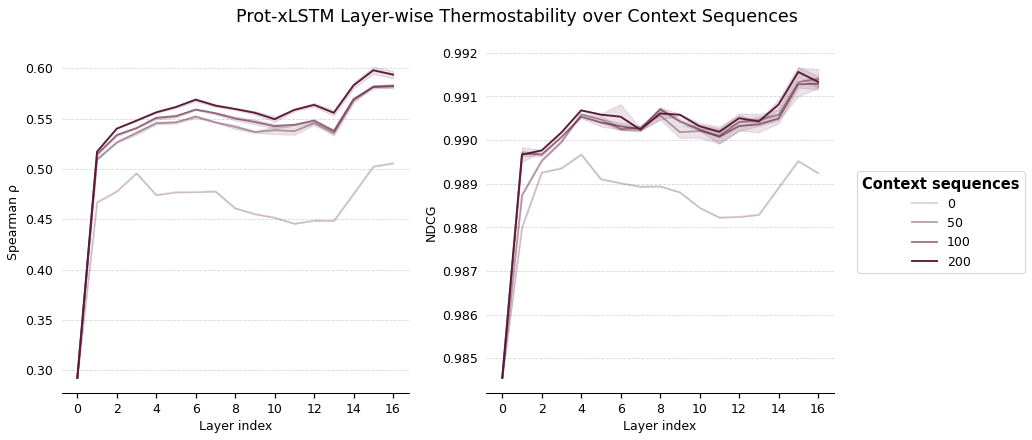

In [7]:
# ── Figure ────────────────────────────────────────────────────────────────────
tasks = [TASKS[7]]
nrows = len(tasks)
fig, axs = plt.subplots(nrows, 2, figsize=(14,6))

color_legend = [
    Line2D([0], [0], marker="o", color="#5C1A3A", lw=2, label="Prot-xLSTM"),
    Line2D([0], [0], marker="o", color="#5E8560", lw=2, label="ProtMamba"),
    Line2D([0], [0], marker="o", color="#DDAA33", lw=2, label="PoET"),
]

marker_legend = [
    Line2D([0], [0], marker=".", color="black", linestyle="", label="Small"),
    Line2D([0], [0], marker="o", color="black", linestyle="", label="Large"),
]

for m, metric in enumerate(["test_performance_2", "test_performance_1"]):
    for row, task in enumerate(tasks):
        first_row = row == 0
        last_row = row == nrows-1

        if row == nrows:
            break

        # ── (B) Layer-wise scaling ────────────────────────────────────────────────────
        ax = axs[m]
        model = "protxlstm_102M_60B"
        color = ARCH_COLOR["protxlstm"]
        for seq_num in [0, 50, 100, 200]:
            mean, std = avg_last_layer(sub)
            ys.append(mean)
            yerrs.append(std)
        
            ls  = MODEL_LINESTYLE[model]
            sub = _rows(df, model, task, seq_num=seq_num, metric=metric)
            if sub.empty:
                continue
            mean, std = avg_layers(sub)
            x = np.arange(len(mean))
            ax.plot(x, mean, label=seq_num, alpha=(seq_num+50) / 250, color=color, linestyle=ls, linewidth=1.8)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)
        
        ax.set_ylabel(METRIC_LABELS[metric][task])
        if last_row:
            ax.set_xlabel("Layer index")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax.legend(title="Context sequences", title_fontproperties={'weight': 'bold'},  loc="center left", bbox_to_anchor=(1.05, 0.5))

plt.suptitle("Prot-xLSTM Layer-wise Thermostability over Context Sequences")


fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"thermo_pretraining_layer_scaling{ext}"),
                bbox_inches="tight", dpi=150)

plt.show()

# Ablations

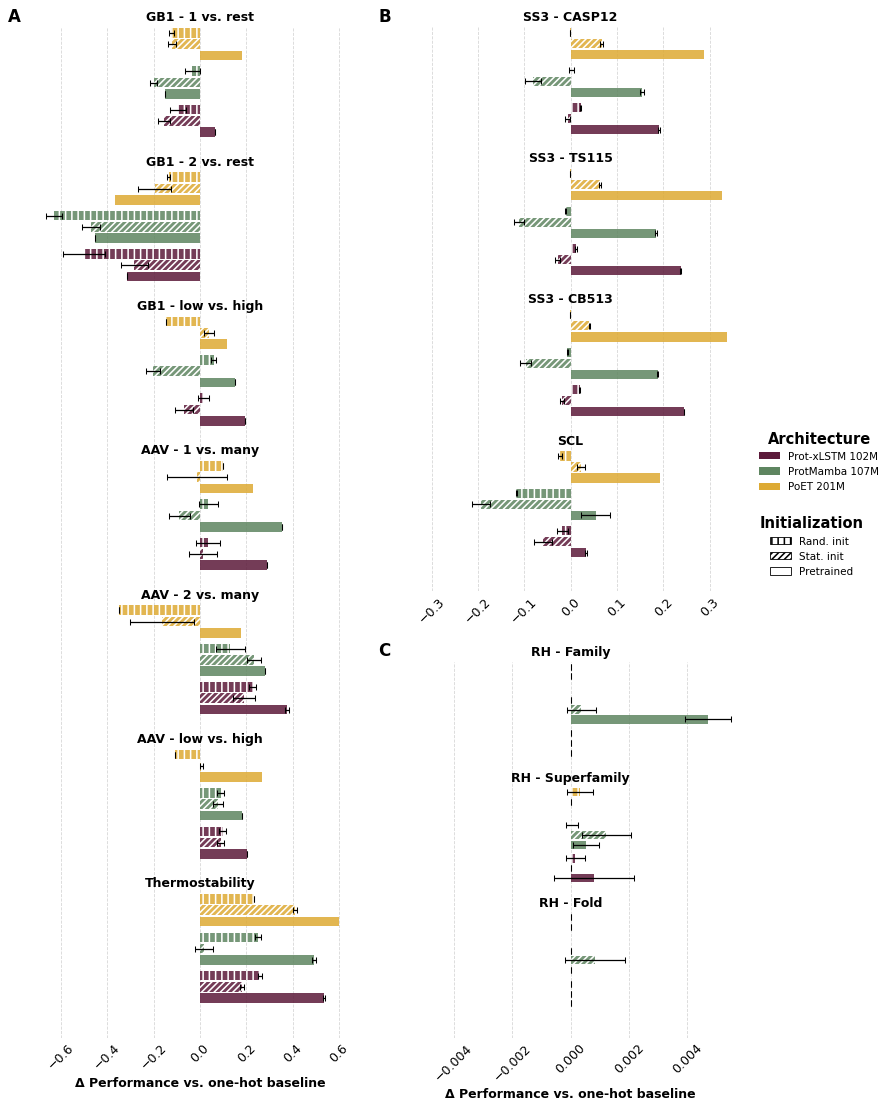

In [3]:

MODELS = {
    "protxlstm": "protxlstm_102M_60B",
    "protmamba": "protmamba_107M_195B",
    "poet":      "poet_201M",
}
ARCH_LABEL = {
    "protxlstm": "Prot-xLSTM 102M",
    "protmamba": "ProtMamba 107M",
    "poet":      "PoET 201M",
}
HATCHES = {
    "pretrained": "",
    "stat":       "////",
    "rand":       "||",
}
COND_LABELS = {
    "pretrained": "Pretrained",
    "stat":       "Stat. init",
    "rand":       "Rand. init",
}

ARCHS      = list(MODELS.keys())
CONDITIONS = ["pretrained", "stat", "rand"]

plt.rcParams.update({'hatch.color': 'white'})

# ── Task groups ────────────────────────────────────────────────────────────────
spearman_tasks  = [t for t in TASKS if t.startswith("proeng")]
structure_tasks = [t for t in TASKS if t.startswith("structure") or t.startswith("annotation")]
evolution_tasks = [t for t in TASKS if t.startswith("evolution")]

# ── Data retrieval ─────────────────────────────────────────────────────────────
def fetch_data(tasks):
    """Returns onehot_vals (n_tasks,) and data[arch][cond] = (means, stds)."""
    # oh_tasks = [t.replace("mean", "flatten") if t.endswith("mean") else t for t in tasks]
    oh_vals  = np.array([get_onehot(t, metric=METRIC) for t in tasks])

    d = {}
    for arch, model in MODELS.items():
        d[arch] = {}
        for cond in CONDITIONS:
            vals = []
            for t in tasks:
                sub = (_rows(df, model, t, metric=METRIC) if cond == "pretrained"
                       else _rows(df, model, t, ptp=0.0, ablation=cond, metric=METRIC))
                vals.append((sub["last_layer"].mean(), sub["last_layer"].std())
                            if not sub.empty else (np.nan, np.nan))
            d[arch][cond] = (np.array([v[0] for v in vals]),
                             np.array([v[1] for v in vals]))
    return oh_vals, d


# ── Drawing helper ─────────────────────────────────────────────────────────────
def draw_butterfly(ax, tasks, oh_vals, data,
                   bar_h=0.10, arch_pad=0.04, task_pad=0.30,
                   show_xlabel=True):
    n_tasks  = len(tasks)
    group_h   = len(CONDITIONS) * bar_h
    cluster_h = len(ARCHS) * group_h + (len(ARCHS) - 1) * arch_pad

    ypos       = {}
    task_ytick = []
    y_cur = 0
    for t in range(n_tasks):
        for a, arch in enumerate(ARCHS):
            group_bot = y_cur + a * (group_h + arch_pad)
            for c, cond in enumerate(CONDITIONS):
                ypos[(t, arch, cond)] = group_bot + c * bar_h + bar_h / 2
        task_ytick.append(y_cur + cluster_h / 2)
        y_cur += cluster_h + task_pad

    for t, task in enumerate(tasks):
        onehot = oh_vals[t]
        for arch in ARCHS:
            color = ARCH_COLOR[arch]
            for cond in CONDITIONS:
                means, stds = data[arch][cond]
                delta = means[t] - onehot
                err   = stds[t]
                y     = ypos[(t, arch, cond)]
                ax.barh(
                    y, delta,
                    height=bar_h * 0.85,
                    color=color,
                    hatch=HATCHES[cond],
                    # edgecolor="black",
                    linewidth=0.5,
                    alpha=0.85,
                    xerr=None if np.isnan(err) else err,
                    error_kw={"capsize": 3, "elinewidth": 1.2, "capthick": 1},
                )

    # ax.axvline(0, color="black", linewidth=1.5, zorder=5)

    # for t in range(n_tasks - 1):
    #     sep_y = task_ytick[t] + cluster_h / 2 + task_pad / 2
    #     ax.axhline(sep_y, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

    # ax.set_yticks(task_ytick)
    # ax.set_yticklabels([TASK_LABELS[t] for t in tasks], fontsize=12, fontweight="bold")
    

    ax.set_yticks([])
    for t, task in enumerate(tasks):
        top_y = task_ytick[t] + cluster_h / 2 + bar_h * 0.3
        ax.text(
            0, top_y,
            TASK_LABELS[task],
            # transform=ax.get_yaxis_transform(),  # x=axes coords [0–1], y=data coords
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold',
        )
    ax.set_ylim(-task_pad, y_cur - task_pad)

    if show_xlabel:
        ax.set_xlabel("Δ Performance vs. one-hot baseline", fontsize=12, fontweight="bold")

    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.grid(False)
    ax.grid(axis="x")

    ax.tick_params(axis="x", rotation=45, length=0)
    xmin, xmax = ax.get_xlim()
    bound = max(abs(xmin), abs(xmax))
    ax.set_xlim(-bound, bound)


# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 15))
gs  = fig.add_gridspec(2, 2, height_ratios=[3, 2], width_ratios=[1, 1])

ax_big    = fig.add_subplot(gs[:, 0])
ax_small1 = fig.add_subplot(gs[0, 1])
ax_small2 = fig.add_subplot(gs[1, 1])#, sharex=ax_small1)

oh_spearman,  d_spearman  = fetch_data(spearman_tasks)
oh_structure, d_structure = fetch_data(structure_tasks)
oh_evolution, d_evolution = fetch_data(evolution_tasks)

draw_butterfly(ax_big,    spearman_tasks,  oh_spearman,  d_spearman,  show_xlabel=True)
draw_butterfly(ax_small1, structure_tasks, oh_structure, d_structure, show_xlabel=False)
draw_butterfly(ax_small2, evolution_tasks, oh_evolution, d_evolution, show_xlabel=True)

ax_big.set_title("A", fontweight="bold", x=-0.05, fontsize=16)
ax_small1.set_title("B", fontweight="bold", x=-0.05, fontsize=16)
ax_small2.set_title("C", fontweight="bold", x=-0.05, fontsize=16)

# ── Shared legend ──────────────────────────────────────────────────────────────
arch_patches = [
    mpatches.Patch(facecolor=ARCH_COLOR[a],  linewidth=0.8, label=ARCH_LABEL[a])
    for a in ARCHS
]
cond_patches = [
    mpatches.Patch(facecolor="white", hatch=HATCHES[c], edgecolor="black", linewidth=0.8, label=COND_LABELS[c])
    for c in CONDITIONS
]

leg1 = ax_small1.legend(handles=cond_patches[::-1],  title_fontproperties={'weight': 'bold'}, title="Initialization", loc="center left", frameon=False, fontsize=10, bbox_to_anchor=(1.03,0.08)) # -0.3
ax_small1.add_artist(leg1)

ax_small1.legend(handles=arch_patches, title_fontproperties={'weight': 'bold'}, title="Architecture",  loc="center left", frameon=False, fontsize=10, bbox_to_anchor=(1.03,0.23))

fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"butterfly_chart-{METRIC}{ext}"), bbox_inches="tight", dpi=150)
plt.show()


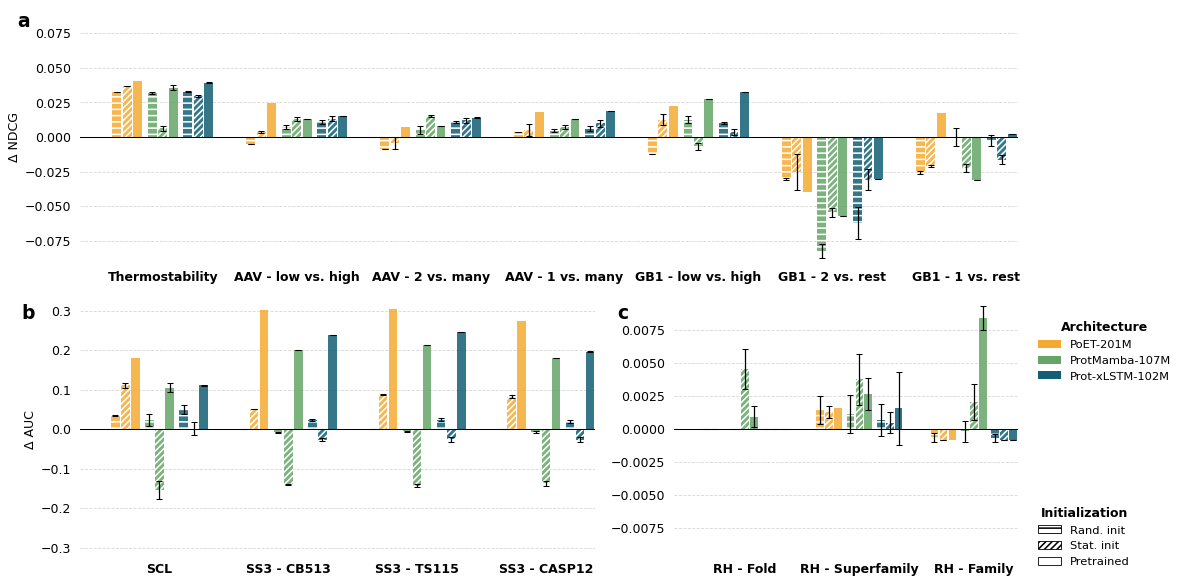

In [12]:

MODELS = {
    "protxlstm": "protxlstm_102M_60B",
    "protmamba": "protmamba_107M_195B",
    "poet":      "poet_201M",
}
ARCH_LABEL = {
    "protxlstm": "Prot-xLSTM-102M",
    "protmamba": "ProtMamba-107M",
    "poet":      "PoET-201M",
}
HATCHES = {
    "pretrained": "",
    "stat":       "////",
    "rand":       "--",
}
COND_LABELS = {
    "pretrained": "Pretrained",
    "stat":       "Stat. init",
    "rand":       "Rand. init",
}

ARCHS      = list(MODELS.keys())[::-1]
CONDITIONS = ["pretrained", "stat", "rand"][::-1]

plt.rcParams.update({'hatch.color': 'white', "ytick.right": False, "xtick.major.size": 0,})

# ── Task groups ────────────────────────────────────────────────────────────────
spearman_tasks  = [t for t in TASKS if t.startswith("proeng")]
structure_tasks = [t for t in TASKS if t.startswith("structure") or t.startswith("annotation")]
evolution_tasks = [t for t in TASKS if t.startswith("evolution")]

# ── Data retrieval ─────────────────────────────────────────────────────────────
def fetch_data(tasks):
    """Returns onehot_vals (n_tasks,) and data[arch][cond] = (means, stds)."""
    # oh_tasks = [t.replace("mean", "flatten") if t.endswith("mean") else t for t in tasks]
    oh_vals  = np.array([get_onehot(t, metric=METRIC) for t in tasks])

    d = {}
    for arch, model in MODELS.items():
        d[arch] = {}
        for cond in CONDITIONS:
            vals = []
            for t in tasks:
                sub = (_rows(df, model, t, metric=METRIC) if cond == "pretrained"
                       else _rows(df, model, t, ptp=0.0, ablation=cond, metric=METRIC))
                vals.append((sub["last_layer"].mean(), sub["last_layer"].std())
                            if not sub.empty else (np.nan, np.nan))
            d[arch][cond] = (np.array([v[0] for v in vals]),
                             np.array([v[1] for v in vals]))
    return oh_vals, d


# ── Drawing helper ─────────────────────────────────────────────────────────────
def draw_butterfly(ax, tasks, oh_vals, data,
                   bar_h=0.10, arch_pad=0.04, task_pad=0.30,
                   show_xlabel=True):
    n_tasks  = len(tasks)
    group_h   = len(CONDITIONS) * bar_h
    cluster_h = len(ARCHS) * group_h + (len(ARCHS) - 1) * arch_pad

    ypos       = {}
    task_ytick = []
    y_cur = 0
    for t in range(n_tasks):
        for a, arch in enumerate(ARCHS):
            group_bot = y_cur + a * (group_h + arch_pad)
            for c, cond in enumerate(CONDITIONS):
                ypos[(t, arch, cond)] = group_bot + c * bar_h + bar_h / 2
        task_ytick.append(y_cur + cluster_h / 2)
        y_cur += cluster_h + task_pad

    for t, task in enumerate(tasks):
        onehot = oh_vals[t]
        for arch in ARCHS:
            color = ARCH_COLOR[arch]
            for cond in CONDITIONS:
                means, stds = data[arch][cond]
                delta = means[t] - onehot
                err   = stds[t]
                y     = ypos[(t, arch, cond)]
                ax.bar(
                    y, delta,
                    width=bar_h * 0.85,
                    color=color,
                    hatch=HATCHES[cond],
                    # edgecolor="black",
                    linewidth=0.5,
                    alpha=0.85,
                    yerr=None if np.isnan(err) else err,
                    error_kw={"capsize": 3, "elinewidth": 1.2, "capthick": 1},
                )

    ax.axhline(0, color="black", linewidth=1, zorder=5)

    # for t in range(n_tasks - 1):
    #     sep_y = task_ytick[t] + cluster_h / 2 + task_pad / 2
    #     ax.axhline(sep_y, color="gray", linewidth=0.5, linestyle="--", alpha=0.5)

    # ax.set_yticks(task_ytick)
    # ax.set_yticklabels([TASK_LABELS[t] for t in tasks], fontsize=12, fontweight="bold")
    

    ax.set_xticks(task_ytick)
    ax.set_xticklabels([TASK_LABELS[t] for t in tasks], fontsize=12, fontweight="bold")
    ax.tick_params(
               bottom=False,
               labelbottom=True)
    
    # for t, task in enumerate(tasks):
    #     top_x = task_ytick[t] + cluster_h / 2 + bar_h * 0.3
    #     ax.text(
    #         0, top_x,
    #         TASK_LABELS[task],
    #         # transform=ax.get_yaxis_transform(),  # x=axes coords [0–1], y=data coords
    #         ha='center',
    #         va='bottom',
    #         fontsize=12,
    #         fontweight='bold',
    #     )
    ax.set_xlim(-task_pad, y_cur - task_pad)
    

    if show_xlabel:
        labels = TASK_METRIC_LABELS_2 if METRIC == "test_performance_2" else TASK_METRIC_LABELS_1
        ax.set_ylabel(f"Δ {labels[task]}", fontsize=12) #, fontweight="bold")


    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.grid(False)
    ax.grid(axis="y")

    # ax.tick_params(axis="y", rotation=45, length=0)
    ymin, ymax = ax.get_ylim()
    bound = max(abs(ymin), abs(ymax))
    ax.set_ylim(-bound, bound)


# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
gs  = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[3, 2])

ax_big    = fig.add_subplot(gs[0, :])
ax_small1 = fig.add_subplot(gs[1, 0])
ax_small2 = fig.add_subplot(gs[1, 1])#, sharex=ax_small1)

oh_spearman,  d_spearman  = fetch_data(spearman_tasks)
oh_structure, d_structure = fetch_data(structure_tasks)
oh_evolution, d_evolution = fetch_data(evolution_tasks)

draw_butterfly(ax_big,    spearman_tasks,  oh_spearman,  d_spearman,  show_xlabel=True)
draw_butterfly(ax_small1, structure_tasks, oh_structure, d_structure, show_xlabel=True)
draw_butterfly(ax_small2, evolution_tasks, oh_evolution, d_evolution, show_xlabel=False)

ax_big.set_title("a", fontweight="bold", x=-0.06, y=0.9, fontsize=18)
ax_small1.set_title("b", fontweight="bold", x=-0.1, y=0.9, fontsize=18)
ax_small2.set_title("c", fontweight="bold", x=-0.15, y=0.9, fontsize=18)

# ── Shared legend ──────────────────────────────────────────────────────────────
arch_patches = [
    mpatches.Patch(facecolor=ARCH_COLOR[a],  linewidth=0.8, label=ARCH_LABEL[a])
    for a in ARCHS
]
cond_patches = [
    mpatches.Patch(facecolor="white", hatch=HATCHES[c], edgecolor="black", linewidth=0.8, label=COND_LABELS[c])
    for c in CONDITIONS
]

leg1 = ax_small2.legend(handles=cond_patches,  title_fontproperties={'weight': 'bold', 'size': 12}, title="Initialization", loc="center left", frameon=False, fontsize=11, bbox_to_anchor=(1.03,0.085)) # -0.3
ax_small2.add_artist(leg1)

ax_small2.legend(handles=arch_patches, title_fontproperties={'weight': 'bold', 'size': 12}, title="Architecture",  loc="center left", frameon=False, fontsize=11, bbox_to_anchor=(1.03,0.8))

fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"butterfly_chart-{METRIC}{ext}"), bbox_inches="tight", dpi=150)
plt.show()


In [35]:

ROOT = ".."

def read_result(task, ablation, arch, model, seeds=[0,35,42,444,12345]):
    subfolder, eval_framework, test_split = TASK_INFO[task]
    agg = "noflatten" if "structure" in subfolder else "mean" 

    if eval_framework == "pytorch":
        if METRIC == "test_performance_1":
            test_metric = "top5_acc" if "evolution" in subfolder else "rocauc"
        else:
            test_metric = "acc"
    else:
        test_metric = 'ndcg' if METRIC == "test_performance_1" else "rho"

    last_layer = MODEL_LAYERS[model]
    
    if ablation == "pretrained":
        results_dir = f"{eval_framework}-{arch}"
    else:
        results_dir = f"{eval_framework}-{arch}-{ablation}"

    vals = []

    for seed in seeds:
        seed_dir = f"seed-{seed}/sampling_seed-42"
        p = os.path.join(ROOT, "results", results_dir, seed_dir, subfolder, model, agg, f"{model}-{agg}-layer_{last_layer}.pkl")
        df_ = pd.read_pickle(p)
        test_perf = df_[test_split][test_metric]
        vals.append(test_perf if test_metric != "rho" else test_perf[0])

    vals = np.array(vals)
    return vals.mean(), vals.std()

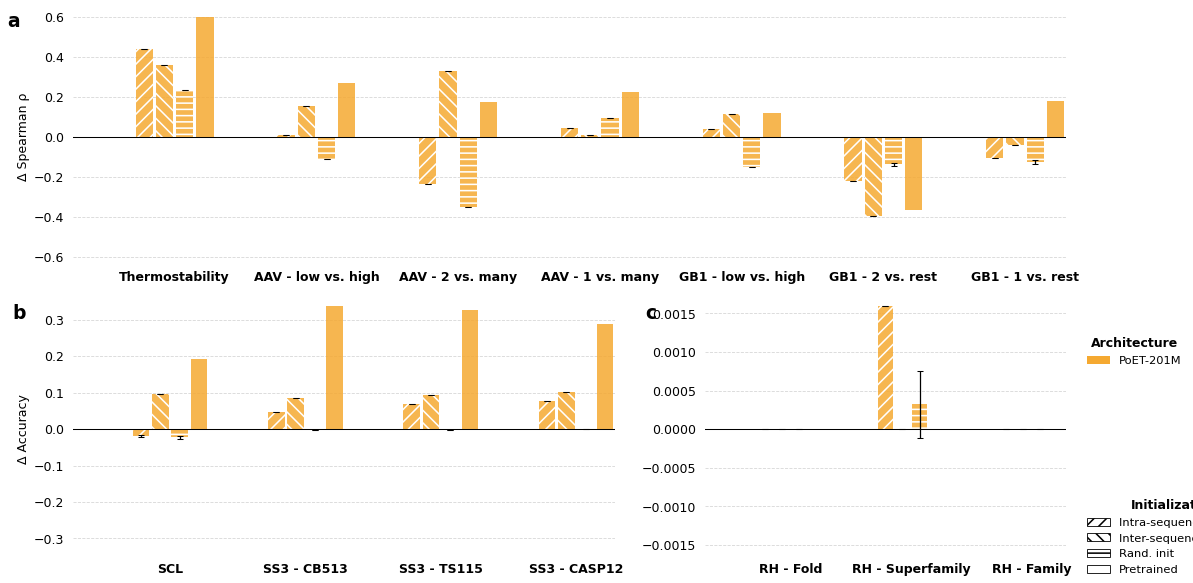

In [ ]:
MODELS = {
    "poet":      "poet_201M",
}
ARCH_LABEL = {
    "poet":      "PoET-201M",
}
HATCHES = {
    "pretrained": "",
    "rand":       "--",
    "rand-inter_seq":  "\\\\",
    "rand-intra_seq":  "//",
}
COND_LABELS = {
    "pretrained": "Pretrained",
    "rand":       "Rand. init",
    "rand-inter_seq": "Inter-sequence rand. init", 
    "rand-intra_seq": "Intra-sequence rand. init",
}

ARCHS      = list(MODELS.keys())[::-1]
CONDITIONS = ["pretrained", "rand", "rand-inter_seq", "rand-intra_seq"][::-1]

plt.rcParams.update({'hatch.color': 'white', "ytick.right": False, "xtick.major.size": 0,})

# ── Task groups ────────────────────────────────────────────────────────────────
spearman_tasks  = [t for t in TASKS if t.startswith("proeng")]
structure_tasks = [t for t in TASKS if t.startswith("structure") or t.startswith("annotation")]
evolution_tasks = [t for t in TASKS if t.startswith("evolution")]

# ── Data retrieval ─────────────────────────────────────────────────────────────
def fetch_data(tasks):
    """Returns onehot_vals (n_tasks,) and data[arch][cond] = (means, stds)."""
    # oh_tasks = [t.replace("mean", "flatten") if t.endswith("mean") else t for t in tasks]
    oh_vals  = np.array([get_onehot(t, metric=METRIC) for t in tasks])

    d = {}
    for arch, model in MODELS.items():
        d[arch] = {}
        for cond in CONDITIONS:
            vals = []
            for t in tasks:
                if cond in ["rand-inter_seq", "rand-intra_seq"]:
                    vals.append(read_result(t, ablation=cond, arch=arch, model=model))
                else:
                    sub = (_rows(df, model, t, metric=METRIC) if cond == "pretrained"
                        else _rows(df, model, t, ptp=0.0, ablation=cond, metric=METRIC))
                    vals.append((sub["last_layer"].mean(), sub["last_layer"].std())
                                if not sub.empty else (np.nan, np.nan))
            d[arch][cond] = (np.array([v[0] for v in vals]),
                             np.array([v[1] for v in vals]))
    return oh_vals, d


# ── Drawing helper ─────────────────────────────────────────────────────────────
def draw_butterfly(ax, tasks, oh_vals, data,
                   bar_h=0.10, arch_pad=0.04, task_pad=0.30,
                   show_xlabel=True):
    n_tasks  = len(tasks)
    group_h   = len(CONDITIONS) * bar_h
    cluster_h = len(ARCHS) * group_h + (len(ARCHS) - 1) * arch_pad

    ypos       = {}
    task_ytick = []
    y_cur = 0
    for t in range(n_tasks):
        for a, arch in enumerate(ARCHS):
            group_bot = y_cur + a * (group_h + arch_pad)
            for c, cond in enumerate(CONDITIONS):
                ypos[(t, arch, cond)] = group_bot + c * bar_h + bar_h / 2
        task_ytick.append(y_cur + cluster_h / 2)
        y_cur += cluster_h + task_pad

    for t, task in enumerate(tasks):
        onehot = oh_vals[t]
        for arch in ARCHS:
            color = ARCH_COLOR[arch]
            for cond in CONDITIONS:
                means, stds = data[arch][cond]
                delta = means[t] - onehot
                err   = stds[t]
                y     = ypos[(t, arch, cond)]
                ax.bar(
                    y, delta,
                    width=bar_h * 0.85,
                    color=color,
                    hatch=HATCHES[cond],
                    # edgecolor="black",
                    linewidth=0.5,
                    alpha=0.85,
                    yerr=None if np.isnan(err) else err,
                    error_kw={"capsize": 3, "elinewidth": 1.2, "capthick": 1},
                )

    ax.axhline(0, color="black", linewidth=1, zorder=5)
    

    ax.set_xticks(task_ytick)
    ax.set_xticklabels([TASK_LABELS[t] for t in tasks], fontsize=12, fontweight="bold")
    ax.tick_params(
               bottom=False,
               labelbottom=True)

    ax.set_xlim(-task_pad, y_cur - task_pad)
    

    if show_xlabel:
        labels = TASK_METRIC_LABELS_2 if METRIC == "test_performance_2" else TASK_METRIC_LABELS_1
        ax.set_ylabel(f"Δ {labels[task]}", fontsize=12) #, fontweight="bold")


    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.grid(False)
    ax.grid(axis="y")

    ymin, ymax = ax.get_ylim()
    bound = max(abs(ymin), abs(ymax))
    ax.set_ylim(-bound, bound)


# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8))
gs  = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[3, 2])

ax_big    = fig.add_subplot(gs[0, :])
ax_small1 = fig.add_subplot(gs[1, 0])
ax_small2 = fig.add_subplot(gs[1, 1])

oh_spearman,  d_spearman  = fetch_data(spearman_tasks)
oh_structure, d_structure = fetch_data(structure_tasks)
oh_evolution, d_evolution = fetch_data(evolution_tasks)

draw_butterfly(ax_big,    spearman_tasks,  oh_spearman,  d_spearman,  show_xlabel=True)
draw_butterfly(ax_small1, structure_tasks, oh_structure, d_structure, show_xlabel=True)
draw_butterfly(ax_small2, evolution_tasks, oh_evolution, d_evolution, show_xlabel=False)

ax_big.set_title("a", fontweight="bold", x=-0.06, y=0.9, fontsize=18)
ax_small1.set_title("b", fontweight="bold", x=-0.1, y=0.9, fontsize=18)
ax_small2.set_title("c", fontweight="bold", x=-0.15, y=0.9, fontsize=18)

# ── Shared legend ──────────────────────────────────────────────────────────────
arch_patches = [
    mpatches.Patch(facecolor=ARCH_COLOR[a],  linewidth=0.8, label=ARCH_LABEL[a])
    for a in ARCHS
]
cond_patches = [
    mpatches.Patch(facecolor="white", hatch=HATCHES[c], edgecolor="black", linewidth=0.8, label=COND_LABELS[c])
    for c in CONDITIONS
]

leg1 = ax_small2.legend(handles=cond_patches,  title_fontproperties={'weight': 'bold', 'size': 12}, title="Initialization", loc="center left", frameon=False, fontsize=11, bbox_to_anchor=(1.03,0.085)) # -0.3
ax_small2.add_artist(leg1)

ax_small2.legend(handles=arch_patches, title_fontproperties={'weight': 'bold', 'size': 12}, title="Architecture",  loc="center left", frameon=False, fontsize=11, bbox_to_anchor=(1.03,0.8))

fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"butterfly_chart-poet_ablations-{METRIC}{ext}"), bbox_inches="tight", dpi=150)
plt.show()


# extrapolation experiments

In [3]:
ROOT = ".."

def read_result(task, ablation, arch, model, seeds=[0,35,42,444,12345], msa_seeds=[42, 12345, 0]):
    subfolder, eval_framework, test_split = TASK_INFO[task]
    agg = "noflatten" if "structure" in subfolder else "mean" 

    if eval_framework == "pytorch":
        if METRIC == "test_performance_1":
            test_metric = "top5_acc" if "evolution" in subfolder else "rocauc"
        else:
            test_metric = "acc"
    else:
        test_metric = 'ndcg' if METRIC == "test_performance_1" else "rho"

    last_layer = MODEL_LAYERS[model]
    
    if ablation == "pretrained":
        results_dir = f"{eval_framework}-{arch}"
    else:
        results_dir = f"{eval_framework}-{arch}-{ablation}"

    vals = []

    for seed in seeds:
        for msa_seed in msa_seeds:
            seed_dir = f"seed-{seed}/sampling_seed-{msa_seed}"
            p = os.path.join(ROOT, "results", results_dir, seed_dir, subfolder, model, agg, f"{model}-{agg}-layer_{last_layer}.pkl")
            df_ = pd.read_pickle(p)
            test_perf = df_[test_split][test_metric]
            vals.append(test_perf if test_metric != "rho" else test_perf[0])

    vals = np.array(vals)
    return vals.mean(), vals.std()

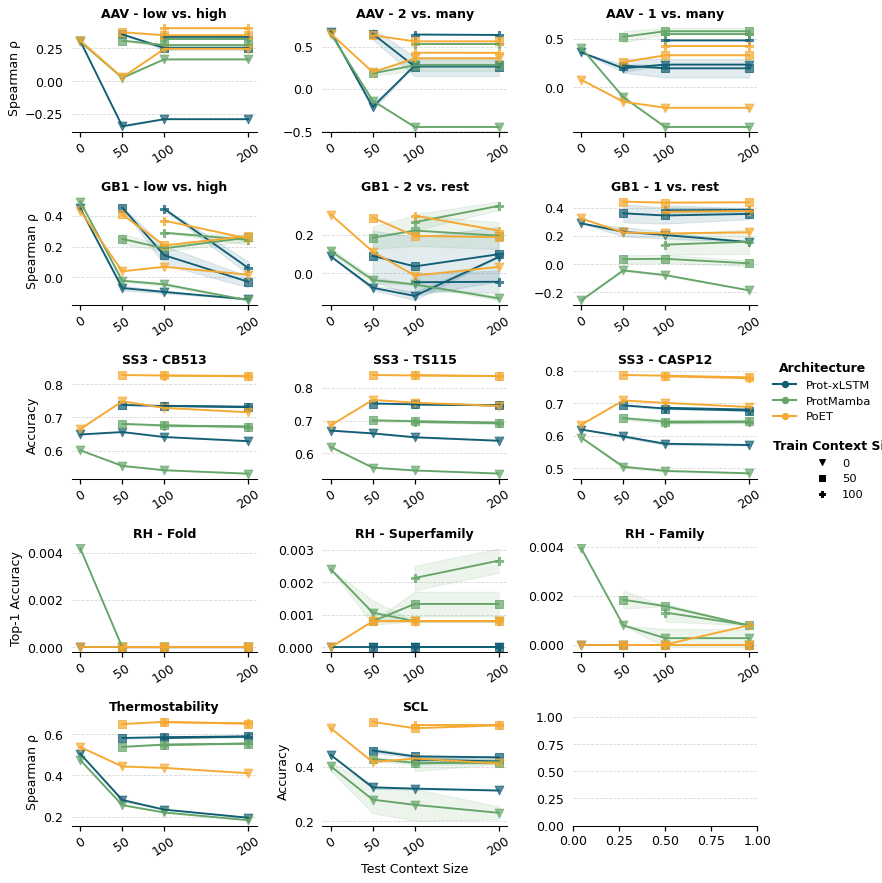

In [82]:
MODELS = {
    "protxlstm": "protxlstm_102M_60B",
    "protmamba": "protmamba_107M_195B",
    "poet":      "poet_201M",
}
ARCH_LABEL = {
    "protxlstm": "Prot-xLSTM-102M",
    "protmamba": "ProtMamba-107M",
    "poet":      "PoET-201M",
}
HATCHES = {
    "pretrained": "",
}
MARKER_LABELS = {
    "maxseq_0": 0,
    "maxseq_50": 50,
    "maxseq_100": 100
}

MARKERS = {
    "maxseq_0": "v",
    "maxseq_50": "s",
    "maxseq_100": "P",
}

ARCHS      = list(MODELS.keys())[::-1]
CONDITIONS = ["pretrained"] + [f"maxseq_{i}_{j}" for j in [0, 50, 100, 200] for i in [0, 50, 100, 200] if j > i] + [f"maxseq_{i}" for i in [0, 50, 100]]

marker_legend = [
    Line2D([0], [0], marker=MARKERS["maxseq_0"], color="black", linestyle="", lw=2, label=MARKER_LABELS["maxseq_0"]),
    Line2D([0], [0], marker=MARKERS["maxseq_50"], color="black", linestyle="", lw=2, label=MARKER_LABELS["maxseq_50"]),
    Line2D([0], [0], marker=MARKERS["maxseq_100"], color="black", linestyle="", lw=2, label=MARKER_LABELS["maxseq_100"]),
]

color_legend = [
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protxlstm"], lw=2, label="Prot-xLSTM"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["protmamba"], lw=2, label="ProtMamba"),
    Line2D([0], [0], marker="o", color=ARCH_COLOR["poet"], lw=2, label="PoET"),
]

plt.rcParams.update({'hatch.color': 'white', "ytick.right": False, "xtick.major.size": 5})

# ── Data retrieval ─────────────────────────────────────────────────────────────
def fetch_data(tasks):
    """Returns onehot_vals (n_tasks,) and data[arch][cond] = (means, stds)."""
    oh_vals  = np.array([get_onehot(t, metric=METRIC) for t in tasks])

    d = {}
    for arch, model in MODELS.items():
        d[arch] = {}
        for cond in CONDITIONS:
            vals = []
            for t in tasks:
                if cond not in ["rand", "stat", "pretrained"]:
                    vals.append(read_result(t, ablation=cond, arch=arch, model=model, seeds=[42], msa_seeds=[42, 12345, 0] if arch != "poet" else [42]))
                else:
                    sub = (_rows(df, model, t, metric=METRIC) if cond == "pretrained"
                        else _rows(df, model, t, ptp=0.0, ablation=cond, metric=METRIC))
                    vals.append((sub["last_layer"].mean(), sub["last_layer"].std())
                                if not sub.empty else (np.nan, np.nan))
            d[arch][cond] = (np.array([v[0] for v in vals]),
                             np.array([v[1] for v in vals]))
    return oh_vals, d

CONTEXT_LENS = np.array([0, 50, 100, 200])


def plot_context_extrapolation(ax, task, data):
    for arch, model in MODELS.items():
        
        for i, train_context_len in enumerate(CONTEXT_LENS):
            test_context_lens = CONTEXT_LENS[CONTEXT_LENS >= train_context_len]
            vals = np.empty((2, len(test_context_lens)))
            if len(test_context_lens) < 2:
                continue
            
            for j, test_context_len in enumerate(test_context_lens):
                key = f"maxseq_{train_context_len}_{test_context_len}" if train_context_len != test_context_len else f"maxseq_{train_context_len}"
                means, stds = data[arch][key]
                vals[:, j] = means[0], stds[0]

            
            color = ARCH_COLOR[arch]
            ls    = MODEL_LINESTYLE[model]
            marker = MARKERS[f"maxseq_{train_context_len}"]
           
            ax.plot(test_context_lens, vals[0], linewidth=1.8, color=color, ls=ls)
            ax.scatter(test_context_lens, vals[0], color=color, marker=marker, label=MARKER_LABELS[f"maxseq_{train_context_len}"], alpha=0.7, s=70)
            ax.fill_between(test_context_lens, vals[0] - vals[1], vals[0] + vals[1],alpha=0.12, color=color)
    ax.set_title(TASK_LABELS[task], fontdict={"size": 12})
    ax.set_xticks(CONTEXT_LENS, labels=CONTEXT_LENS, rotation=33)

# ── Figure ─────────────────────────────────────────────────────────────────────
nrows = 5
ncols = 3 # (len(TASKS) // nrows) + 1 if len(TASKS) % nrows != 0 else len(TASKS) // nrows
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 12))

# figsize=(12,10.5))

aav_tasks = TASKS[1:4]
gb1_tasks = TASKS[4:7]
ss3_tasks = TASKS[8:11]
rh_tasks = TASKS[11:14]
other_tasks = [TASKS[0], TASKS[7]]

tasks = aav_tasks + gb1_tasks + ss3_tasks + rh_tasks + other_tasks

for t, task in enumerate(tasks):
    _, data = fetch_data([task])
    row, col = t // ncols, t % ncols
    plot_context_extrapolation(axes[row, col], task, data)
    if col == 0:
        labels = TASK_METRIC_LABELS_2 if METRIC == "test_performance_2" else TASK_METRIC_LABELS_1
        axes[row, col].set_ylabel(f"{labels[task]}")
    if col == 1 and row == nrows-1:
        axes[row, col].set_xlabel(f"Test Context Size", fontsize=12)
    if col == ncols-1 and row == nrows // 2:
        leg1 = axes[row, col].legend(handles=marker_legend, title_fontproperties={'weight': 'bold', 'size': 12}, title="Train Context Size",  loc="center left", frameon=False, fontsize=11, bbox_to_anchor=(1.03,0.085))
        axes[row, col].add_artist(leg1)
        axes[row, col].legend(handles=color_legend, title_fontproperties={'weight': 'bold', 'size': 12}, title="Architecture",  loc="center left", frameon=False, fontsize=11, bbox_to_anchor=(1.03,0.8))
    if t == len(tasks)-1:
        axes[row, col].set_ylabel(f"{labels[task]}")

fig.tight_layout()
for ext in [".svg", ".png"]:
    fig.savefig(os.path.join(OUT_DIR, f"butterfly_chart-context_extrapolation-{METRIC}{ext}"), bbox_inches="tight", dpi=150)
plt.show()


## Export homology-aware CLM experiment overview

In [13]:
# create summary results tables with pandas

arch_models = {
    "protxlstm": [("small", "protxlstm_26M_30B"), ("large", "protxlstm_102M_60B")],
    "protmamba": [("small", "protmamba_28M_30B"), ("large", "protmamba_107M_195B")],
    "poet": [("large", "poet_201M")] }

per_arch = False

sample_seeds = [42, 0, 12345]
n_sample_seeds = len(sample_seeds)

columns = ["task", "tl>oh", "tl>rand","tl>stat", "model_size", "model_depth", "pretrain", "context_size"]

result_df = pd.DataFrame(columns=columns)
result_summary = defaultdict(lambda: 0)
for t in TASKS[:]:
    print(t)
    if not per_arch:
        result_summary = defaultdict(lambda: 0)
        result_summary["task"] = TASK_LABELS[t]

    # onehot
    for model in ["protxlstm_102M_60B", "protmamba_107M_195B", "poet_201M"]:
        n_sample_seeds = len(sample_seeds) if model != "poet_201M" else 1
        if per_arch:
            result_summary = defaultdict(lambda: 0)
            result_summary["task"] = TASK_LABELS[t]
        # oh_task = t.replace("mean", "flatten") if t.endswith("mean") else t
        oh_perf = get_onehot(t, metric=METRIC)
        rand_perf = get_ablation_results(df, model, t, "rand", metric=METRIC)
        stat_perf = get_ablation_results(df, model, t, "stat", metric=METRIC)
        tl_perf = _rows(df, model, t, metric=METRIC).set_index("sampleseed")

        if model != "poet_201M":
            arch = model.split("_")[0]
            small_tl_perf = _rows(df, arch_models[arch][0][1], t, metric=METRIC).set_index("sampleseed")
            large_tl_perf = _rows(df, arch_models[arch][1][1], t, metric=METRIC).set_index("sampleseed")

            if per_arch:
                result_summary["tl>oh"] = ((small_tl_perf["last_layer"] > oh_perf) & (large_tl_perf["last_layer"] > oh_perf)).sum() / n_sample_seeds

            else:
                print(model)
                print(small_tl_perf["last_layer"] > oh_perf)
                print(large_tl_perf["last_layer"] > oh_perf)
                result_summary["tl>oh"] += (((small_tl_perf["last_layer"] > oh_perf) & (large_tl_perf["last_layer"] > oh_perf)).sum() / n_sample_seeds) > 0.5
        else:
            if per_arch:
                result_summary["tl>oh"] = (tl_perf["last_layer"] > oh_perf).sum() / n_sample_seeds

            else:
                result_summary["tl>oh"] += ((tl_perf["last_layer"] > oh_perf).sum() / n_sample_seeds) > 0.5

        for abl, abl_perf in zip(["rand", "stat"], [rand_perf, stat_perf]):
            # merge wrt sample seeds
            merged_df = pd.merge(abl_perf[["mean", "p_value"]], tl_perf[["last_layer"]], left_index=True, right_index=True)
            mask = (merged_df["last_layer"] > merged_df["mean"]) & (merged_df["p_value"] < 0.05)
            if per_arch:
                result_summary[f"tl>{abl}"] = mask.sum() / n_sample_seeds
            else: 
                result_summary[f"tl>{abl}"] += (mask.sum() / n_sample_seeds) > 0.5

        # scaling
        arch = model.split("_")[0]
        if per_arch:
            result_summary["arch"] = arch
        tl_perf = {}

        # modelsize
        for size_cat, model_name in arch_models[arch]:
            tl_perf[size_cat] = _rows(df, model_name, t, metric=METRIC).set_index("sampleseed")["last_layer"]

        if len(tl_perf) > 1:
            tl_perf = pd.merge(tl_perf["small"], tl_perf["large"], left_index=True, right_index=True)
            # print(tl_perf)
            if per_arch:
                result_summary["model_size"] = (tl_perf["last_layer_x"] < tl_perf["last_layer_y"]).sum() / n_sample_seeds
            else:
                result_summary["model_size"] += ((tl_perf["last_layer_x"] < tl_perf["last_layer_y"]).sum() / n_sample_seeds) > 0.5

        # depth
        layer_result = [spearmanr(range(0, len(lp)), lp) for lp in _rows(df, model, t, metric=METRIC).set_index("sampleseed")["value_list"]]
        layer_result = pd.DataFrame(layer_result, columns=["rho", "p_value"])
        if per_arch:
            result_summary["model_depth"] = ((layer_result["rho"] > 0.9) & (layer_result["p_value"] < 0.05)).sum() / n_sample_seeds
        else:
            result_summary["model_depth"] += (((layer_result["rho"] > 0.9) & (layer_result["p_value"] < 0.05)).sum() / n_sample_seeds) > 0.5

        # pretrain_loss
        pretrain_points = np.sort(df[df["arch"] == arch].ptp.unique())
        perfs = defaultdict(list)
        if len(pretrain_points) > 2:
            perfs = defaultdict(list)
            for ptp in pretrain_points[1:]:
                pt_perf = _rows(df, model, t, metric=METRIC, ptp=ptp).set_index("sampleseed")
                for sampleseed in _rows(df, model, t, metric=METRIC).sampleseed:
                    perfs[sampleseed].append(pt_perf.loc[sampleseed, "last_layer"])

            pretrain_result = [spearmanr(range(0, len(p)), p) for p in perfs.values()]
            pretrain_result = pd.DataFrame(pretrain_result, columns=["rho", "p_value"])
            if per_arch:
                result_summary["pretrain"] = ((pretrain_result["rho"] > 0.9) & (pretrain_result["p_value"] < 0.05)).sum() / n_sample_seeds
            else:
                result_summary["pretrain"] += (((pretrain_result["rho"] > 0.9) & (pretrain_result["p_value"] < 0.05)).sum() / n_sample_seeds) > 0.5

        # context len
        max_seq_nums = np.sort(df[df["arch"] == arch].max_seq_num.unique())
        
        if len(max_seq_nums) > 1:
            perfs = defaultdict(list)
            is_increasing = []
            for seq_num in max_seq_nums:
                seq_num_perf = _rows(df, model, t, metric=METRIC, seq_num=seq_num).set_index("sampleseed")
                for sampleseed in _rows(df, model, t, metric=METRIC).sampleseed:
                    perfs[sampleseed].append(seq_num_perf.loc[sampleseed, "last_layer"])

            for sampleseed in _rows(df, model, t, metric=METRIC).sampleseed:
                is_increasing.append(pd.Series(perfs[sampleseed]).is_monotonic_increasing)
            if per_arch:
                result_summary["context_size"] = sum(is_increasing) / n_sample_seeds
            else:
                result_summary["context_size"] += (sum(is_increasing) / n_sample_seeds) > 0.5
        if per_arch:
            result_df.loc[len(result_df)] = result_summary

    
    if not per_arch:
        for col in ["tl>oh", "tl>rand", "tl>stat", "model_depth", "context_size"]:
            result_summary[col] = result_summary[col] / 3
        result_summary["model_size"] = result_summary["model_size"] / 2
        result_df.loc[len(result_df)] = result_summary

def arch_label(arch):
    trans_dict = {"protxlstm": "Prot-xLSTM", "protmamba": "ProtMamba", "poet": "PoET"}
    return trans_dict[arch]
def label(x):
    if x >= 0.9:
        return "\\checkmark"
    elif x <= 0.1:
        return "\\xmark"
    else:
        return "$\\sim$"

formatters = {col: label for col in result_df.columns[1:]}
formatters.update({"arch": arch_label})

print(result_df.to_latex(index=False, formatters=formatters, na_rep="-"))

proeng_thermo_mixed_split_mean
protxlstm_102M_60B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
protmamba_107M_195B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
proeng_aav_low_vs_high_mean
protxlstm_102M_60B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
protmamba_107M_195B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, 

/system/apps/studentenv/anebner/miniforge3/envs/prot_xlstm/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


structure_secondary_structure_tape_ss3_processed_ts115_noflatten
protxlstm_102M_60B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
protmamba_107M_195B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
structure_secondary_structure_tape_ss3_processed_casp12_noflatten
protxlstm_102M_60B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool


/system/apps/studentenv/anebner/miniforge3/envs/prot_xlstm/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


protmamba_107M_195B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean


/system/apps/studentenv/anebner/miniforge3/envs/prot_xlstm/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


protxlstm_102M_60B
sampleseed
sampling_seed-42       False
sampling_seed-0        False
sampling_seed-12345    False
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       False
sampling_seed-0        False
sampling_seed-12345    False
Name: last_layer, dtype: bool
protmamba_107M_195B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       False
sampling_seed-0         True
sampling_seed-12345     True
Name: last_layer, dtype: bool


/tmp/ipykernel_3850861/1476608843.py:100: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pretrain_result = [spearmanr(range(0, len(p)), p) for p in perfs.values()]


evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean
protxlstm_102M_60B
sampleseed
sampling_seed-42       False
sampling_seed-0        False
sampling_seed-12345    False
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       False
sampling_seed-0        False
sampling_seed-12345     True
Name: last_layer, dtype: bool
protmamba_107M_195B
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       True
sampling_seed-0        True
sampling_seed-12345    True
Name: last_layer, dtype: bool
evolution_remote_homology_tape_rh_processed_test-family-holdout_mean
protxlstm_102M_60B
sampleseed
sampling_seed-42       False
sampling_seed-0        False
sampling_seed-12345    False
Name: last_layer, dtype: bool
sampleseed
sampling_seed-42       False
sampling_seed-0        False
sampling_seed-12345    False
Name: last_layer, dtype: bool
protmamba_107M_195B
sampleseed
sampli

## Export comparison between models for best downstream task performances

In [2]:
# first, run with protran environment and reatet results dataframe and get results for carp and esm & save results
# then, with prot-xlstm environment read saved dataframe and run for rest of models

# results = pd.DataFrame(columns=["model", "arch", "task", "layer", "val_loss", "val_perf_mean", "test_perf_mean", "test_perf_std"])
# models = {a:m for a,m in ARCH_TO_MODEL.items() if m == "carp_76M" or m == "esm1_t12_85M_UR50S"}

results = pd.read_csv(f"./mlm_model_results_{METRIC}.csv")
models = {a:m for a,m in ARCH_TO_MODEL.items() if m == "protxlstm_102M_60B" or m == "protmamba_107M_195B" or m == "poet_201M"}
ROOT = ".."

for m, (arch, model) in enumerate(models.items()):
    if model in ["carp_76M", "esm1_t12_85M_UR50S"]:
        result_dir = "results_li"
        seed_dir = "seed-42"
    else:
        result_dir = "results"
        seed_dir = "seed-42/sampling_seed-42"
    
    model_depth = MODEL_LAYERS[model]
    for t, task in enumerate(TASKS):
        
        subfolder, eval_framework, test_split = TASK_INFO[task]
        agg = "noflatten" if "structure" in subfolder else "mean" 
        if eval_framework == "pytorch":
            if METRIC == "test_performance_1":
                test_metric = "top5_acc" if "evolution" in subfolder else "rocauc"
            else:
                test_metric = "acc"
        else:
            test_metric = 'ndcg' if METRIC == "test_performance_1" else "rho"

        for layer in range(model_depth+1):
            row = {"model": model, "arch": arch, "task": task}
            test_perf_std = np.nan
            if model in ["protxlstm_102M_60B", "protmamba_107M_195B"]:
                msaseeds = [42, 0, 12345]
                val_losses = np.empty(shape=(len(msaseeds),))
                val_perfs = np.empty(shape=(len(msaseeds),))
                test_perfs = np.empty(shape=(len(msaseeds),))
                
                for i, msaseed in enumerate(msaseeds):
                    seed_dir = f"seed-42/sampling_seed-{msaseed}"
                    p = os.path.join(ROOT, result_dir, f"{eval_framework}-{arch}", seed_dir, subfolder, model, agg, f"{model}-{agg}-layer_{layer}.pkl")
                    df_ = pd.read_pickle(p)

                    val_losses[i] = df_["val"]["cross-entropy" if eval_framework =="pytorch" else "mse"]
                    val_perfs[i] = df_["val"][test_metric][0] if test_metric == "rho" else df_["val"][test_metric]
                    test_perfs[i] = df_[test_split][test_metric][0] if test_metric == "rho" else df_[test_split][test_metric]
                
                val_loss = val_losses.mean()
                val_perf = val_perfs.mean()
                test_perf = test_perfs.mean()
                test_perf_std = test_perfs.std()
            else:
                p = os.path.join(ROOT, result_dir, f"{eval_framework}-{arch}", seed_dir, subfolder, model, agg, f"{model}-{agg}-layer_{layer}.pkl")
                df_ = pd.read_pickle(p)
            
                val_loss = df_["val"]["cross-entropy" if eval_framework =="pytorch" else "mse"]
                val_perf = df_["val"][test_metric][0] if test_metric == "rho" else df_["val"][test_metric]
                test_perf = df_[test_split][test_metric][0] if test_metric == "rho" else df_[test_split][test_metric]

            row["layer"] = layer
            row["val_loss"] = val_loss
            row["val_perf_mean"] = val_perf
            row["test_perf_mean"] = test_perf
            row["test_perf_std"] = test_perf_std
        
            results.loc[len(results)] = row

# results.to_csv(f"./mlm_model_results_{METRIC}.csv", index=False)

In [3]:
# add onehot to the results table and save
# results = pd.DataFrame(columns=["model", "arch", "task", "layer", "val_loss", "val_perf_mean", "test_perf_mean", "test_perf_std"])
arch = "one-hot"
model = "onehot"
for t in TASKS:
    row = {"model": model, "arch": arch, "task": t, "layer": 0, "val_loss":0, "val_perf_mean":0}

    # oh_task = t.replace("mean", "flatten") if t.endswith("mean") else t
    row["test_perf_mean"] = get_onehot(t, metric=METRIC)
    results.loc[len(results)] = row

results.to_csv(f"./model_results_{METRIC}.csv", index=False)

In [4]:
results

,model,arch,task,layer,val_loss,val_perf_mean,test_perf_mean,test_perf_std
0,carp_76M,carp,structure_secondary_structure_tape_ss3_process...,0,1.036323,0.458457,0.484564,NaN
1,carp_76M,carp,structure_secondary_structure_tape_ss3_process...,1,0.855911,0.611104,0.570424,NaN
2,carp_76M,carp,structure_secondary_structure_tape_ss3_process...,2,0.742532,0.677102,0.622519,NaN
3,carp_76M,carp,structure_secondary_structure_tape_ss3_process...,3,0.683556,0.706208,0.647189,NaN
4,carp_76M,carp,structure_secondary_structure_tape_ss3_process...,4,0.664367,0.714918,0.649807,NaN
...,...,...,...,...,...,...,...,...
1311,onehot,one-hot,proeng_aav_two_vs_many_mean,0,0.000000,0.000000,0.251603,NaN
1312,onehot,one-hot,proeng_aav_low_vs_high_mean,0,0.000000,0.000000,0.136529,NaN
1313,onehot,one-hot,proeng_gb1_one_vs_rest_mean,0,0.000000,0.000000,0.248811,NaN
1314,onehot,one-hot,proeng_gb1_low_vs_high_mean,0,0.000000,0.000000,0.257220,NaN


In [6]:
results = pd.read_csv(f"./model_results_{METRIC}.csv")

In [7]:
# select best performing layer
tasks_subset = TASKS[:]

tasks_subset_labels = []
for t in tasks_subset:
    tasks_subset_labels.append(TASK_LABELS[t]+"_mean")
    tasks_subset_labels.append(TASK_LABELS[t]+"_std")

tasks_subset_labels

results_comparison = pd.DataFrame(columns=["model"]+tasks_subset_labels)
models = ["onehot", "carp_76M", "esm1_t12_85M_UR50S", "poet_201M", "protmamba_107M_195B", "protxlstm_102M_60B"]
for model in models:
    row = {"model":model}
    for t, task in enumerate(tasks_subset):
    
        sub_df = results[
            (results.model == model) & (results.task == task)
        ]
        idx = np.array(sub_df.val_perf_mean).argmax()
        row[TASK_LABELS[task]+"_mean"] = np.array(sub_df.test_perf_mean)[idx]
        row[TASK_LABELS[task]+"_std"] = np.array(sub_df.test_perf_std)[idx]
        
    results_comparison.loc[len(results_comparison)] = row

print(results_comparison.to_latex(na_rep = "", float_format="%.3f", index=False))

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
model & Thermostability_mean & Thermostability_std & AAV - low vs. high_mean & AAV - low vs. high_std & AAV - 2 vs. many_mean & AAV - 2 vs. many_std & AAV - 1 vs. many_mean & AAV - 1 vs. many_std & GB1 - low vs. high_mean & GB1 - low vs. high_std & GB1 - 2 vs. rest_mean & GB1 - 2 vs. rest_std & GB1 - 1 vs. rest_mean & GB1 - 1 vs. rest_std & SCL_mean & SCL_std & SS3 - CB513_mean & SS3 - CB513_std & SS3 - TS115_mean & SS3 - TS115_std & SS3 - CASP12_mean & SS3 - CASP12_std & RH - Fold_mean & RH - Fold_std & RH - Superfamily_mean & RH - Superfamily_std & RH - Family_mean & RH - Family_std \\
\midrule
onehot & 0.060 &  & 0.137 &  & 0.252 &  & 0.197 &  & 0.257 &  & 0.543 &  & 0.249 &  & 0.377 &  & 0.488 &  & 0.510 &  & 0.491 &  & 0.000 &  & 0.000 &  & 0.000 &  \\
carp_76M & 0.561 &  & 0.288 &  & 0.478 &  & 0.364 &  & 0.470 &  & 0.556 &  & -0.078 &  & 0.569 &  & 0.794 &  & 0.806 &  & 0.701 &  & 0.008 &  & 0.009 &  & 0.017 &  \\
esm1_t12_

# get rank of performances

In [ ]:
results_comparison = results_comparison[[col for col in results_comparison.columns if col[-4:] != "_std"]].set_index("model")
results_comparison = results_comparison.loc[["carp_76M", "esm1_t12_85M_UR50S", "protmamba_107M_195B", "protxlstm_102M_60B"]]

In [17]:
rank_df = results_comparison.rank(axis=0, ascending=False, method="min")

In [18]:
rank_df

,Thermostability_mean,AAV - low vs. high_mean,AAV - 2 vs. many_mean,AAV - 1 vs. many_mean,GB1 - low vs. high_mean,GB1 - 2 vs. rest_mean,GB1 - 1 vs. rest_mean,SCL_mean,SS3 - CB513_mean,SS3 - TS115_mean,SS3 - CASP12_mean,RH - Fold_mean,RH - Superfamily_mean,RH - Family_mean
model,,,,,,,,,,,,,,
carp_76M,2.0,3.0,4.0,2.0,1.0,1.0,4.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0
esm1_t12_85M_UR50S,4.0,4.0,3.0,3.0,2.0,3.0,3.0,2.0,2.0,2.0,4.0,1.0,2.0,2.0
protmamba_107M_195B,3.0,2.0,2.0,1.0,4.0,4.0,2.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0
protxlstm_102M_60B,1.0,1.0,1.0,4.0,3.0,2.0,1.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0


In [71]:
for dataset in ["Thermo", "SCL", "AAV", "GB1", "SS3", "RH"]:
    rank_df[dataset] = rank_df[[col for col in results_comparison.columns if col.startswith(dataset)]].mean(axis=1)

In [ ]:
#  "carp_76M", "esm1_t12_85M_UR50S"

2.2142857142857144

In [75]:
rank_df = rank_df[[col for col in rank_df.columns if not col.endswith("_mean")]]

In [94]:
rank_df.loc[["protmamba_107M_195B","protxlstm_102M_60B"], [col for col in rank_df.columns if col != "RH"]].mean().mean()

2.6

In [69]:
print(rank_df[[col for col in results_comparison.columns if col.startswith("GB1")]].mean(axis=1).to_latex(na_rep = "", float_format="%.3f"))

\begin{tabular}{lr}
\toprule
 & 0 \\
model &  \\
\midrule
carp_76M & 2.000 \\
esm1_t12_85M_UR50S & 2.667 \\
protmamba_107M_195B & 3.333 \\
protxlstm_102M_60B & 2.000 \\
\bottomrule
\end{tabular}



In [19]:
avg_rank = rank_df.mean(axis=1).sort_values()
avg_rank

model
carp_76M               1.785714
esm1_t12_85M_UR50S     2.642857
protmamba_107M_195B    2.642857
protxlstm_102M_60B     2.857143
dtype: float64

In [20]:
print(avg_rank.to_latex(na_rep = "", float_format="%.3f"))

\begin{tabular}{lr}
\toprule
 & 0 \\
model &  \\
\midrule
carp_76M & 1.786 \\
esm1_t12_85M_UR50S & 2.643 \\
protmamba_107M_195B & 2.643 \\
protxlstm_102M_60B & 2.857 \\
\bottomrule
\end{tabular}



In [ ]:
results_comparison = results_comparison[[col for col in results_comparison.columns if col[-4:] != "_std"]].set_index("model")
rank_df = results_comparison.rank(axis=0, ascending=False, method="min")
avg_rank = rank_df.mean(axis=1).sort_values()
avg_rank

print(avg_rank.to_latex(na_rep = "", float_format="%.3f"))  

\begin{tabular}{lr}
\toprule
 & 0 \\
model &  \\
\midrule
carp_76M & 2.357 \\
poet_201M & 2.714 \\
esm1_t12_85M_UR50S & 3.357 \\
protmamba_107M_195B & 3.357 \\
protxlstm_102M_60B & 3.500 \\
onehot & 5.000 \\
\bottomrule
\end{tabular}



## Export comparison between models for last layer downstream task performances

In [9]:
results = pd.read_csv("./model_results_test_performance_1.csv")

# select best performing layer
tasks_subset = TASKS[:]

tasks_subset_labels = []
for t in tasks_subset:
    tasks_subset_labels.append(TASK_LABELS[t]+"_mean")
    tasks_subset_labels.append(TASK_LABELS[t]+"_std")

tasks_subset_labels

results_comparison = pd.DataFrame(columns=["model"]+tasks_subset_labels)
models = ["onehot", "carp_76M", "esm1_t12_85M_UR50S", "poet_201M", "protmamba_107M_195B", "protxlstm_102M_60B"]
for model in models:
    row = {"model":model}
    for t, task in enumerate(tasks_subset):
    
        sub_df = results[
            (results.model == model) & (results.task == task) & (results.layer == MODEL_LAYERS[model])
        ]
        row[TASK_LABELS[task]+"_mean"] = np.array(sub_df.test_perf_mean)[-1]
        row[TASK_LABELS[task]+"_std"] = np.array(sub_df.test_perf_std)[-1]
        
    results_comparison.loc[len(results_comparison)] = row

print(results_comparison.to_latex(na_rep = "", float_format="%.3f", index=False))

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
model & SS3 - CASP12_mean & SS3 - CASP12_std & SS3 - CB513_mean & SS3 - CB513_std & SS3 - TS115_mean & SS3 - TS115_std & RH - Family_mean & RH - Family_std & RH - Superfamily_mean & RH - Superfamily_std & RH - Fold_mean & RH - Fold_std & SCL_mean & SCL_std & Thermostability_mean & Thermostability_std & AAV - 1 vs many_mean & AAV - 1 vs many_std & AAV - 2 vs many_mean & AAV - 2 vs many_std & AAV - low vs high_mean & AAV - low vs high_std & GB1 - 1 vs many_mean & GB1 - 1 vs many_std & GB1 - low vs high_mean & GB1 - low vs high_std & GB1 - 2 vs many_mean & GB1 - 2 vs many_std \\
\midrule
onehot & 0.638 &  & 0.641 &  & 0.644 &  & 0.001 &  & 0.001 &  & 0.000 &  & 0.663 &  & 0.952 &  & 0.961 &  & 0.970 &  & 0.923 &  & 0.873 &  & 0.913 &  & 0.891 &  \\
carp_76M & 0.840 &  & 0.921 &  & 0.928 &  & 0.017 &  & 0.012 &  & 0.011 &  & 0.844 &  & 0.990 &  & 0.968 &  & 0.985 &  & 0.931 &  & 0.850 &  & 0.944 &  & 0.891 &  \\
esm1_t12_85M_UR50S & 0

In [10]:
results_comparison = results_comparison[[col for col in results_comparison.columns if col[-4:] != "_std"]].set_index("model")
rank_df = results_comparison.rank(axis=0, ascending=False, method="min")
avg_rank = rank_df.mean(axis=1).sort_values()
avg_rank

print(avg_rank.to_latex(na_rep = "", float_format="%.3f"))

\begin{tabular}{lr}
\toprule
 & 0 \\
model &  \\
\midrule
carp_76M & 2.571 \\
esm1_t12_85M_UR50S & 2.786 \\
poet_201M & 2.786 \\
protxlstm_102M_60B & 3.071 \\
protmamba_107M_195B & 4.214 \\
onehot & 5.214 \\
\bottomrule
\end{tabular}



# create a table for context ordering experiments

In [ ]:
# create a table for context ordering experiments


import pandas as pd
result_df = pd.DataFrame(columns=("Task", "Model", "Random", "Sorted", "Sorted>Random"))

models = ["protxlstm_26M_30B", "protxlstm_102M_60B", "protmamba_28M_30B", "protmamba_107M_195B"]
result_dirs = {
    "Random": "results",
    "Sorted": "results_sortedmsa",
}

ROOT = ".."
seed_dir = "seed-42/sampling_seed-42"


for t, task in enumerate(TASKS):
    subfolder, eval_framework, test_split = TASK_INFO[task]
    agg = "noflatten" if "structure" in subfolder else "mean" 

    if eval_framework == "pytorch":
        if METRIC == "test_performance_1":
            test_metric = "top5_acc" if "evolution" in subfolder else "rocauc"
        else:
            test_metric = "acc"
    else:
        test_metric = 'ndcg' if METRIC == "test_performance_1" else "rho"

    for m, model in enumerate(models):
        arch = model.split("_")[0]
        row = {"Task": TASK_LABELS[task], "Model": MODEL_LABELS[model]}
        last_layer = MODEL_LAYERS[model]

        for key, result_dir in result_dirs.items():
            
            p = os.path.join(ROOT, result_dir, f"{eval_framework}-{arch}", seed_dir, subfolder, model, agg, f"{model}-{agg}-layer_{last_layer}.pkl")
            df_ = pd.read_pickle(p)

            test_perf = df_[test_split][test_metric]
            row[key] = test_perf if test_metric != "rho" else test_perf[0]
                
        row["Sorted>Random"] = row["Sorted"] > row["Random"]

        result_df.loc[len(result_df)] = row

print(result_df.to_latex(index=False, float_format="%.3f", formatters={"Sorted>Random": lambda x: "\\checkmark" if x else "\\xmark"}))

\begin{tabular}{llrrr}
\toprule
Task & Model & Random & Sorted & Sorted>Random \\
\midrule
SS3 - CASP12 & Prot-xLSTM 26M & 0.645 & 0.643 & \xmark \\
SS3 - CASP12 & Prot-xLSTM 102M & 0.680 & 0.686 & \checkmark \\
SS3 - CASP12 & ProtMamba 28M & 0.628 & 0.626 & \xmark \\
SS3 - CASP12 & ProtMamba 107M & 0.642 & 0.632 & \xmark \\
SS3 - CB513 & Prot-xLSTM 26M & 0.684 & 0.685 & \checkmark \\
SS3 - CB513 & Prot-xLSTM 102M & 0.733 & 0.736 & \checkmark \\
SS3 - CB513 & ProtMamba 28M & 0.648 & 0.647 & \xmark \\
SS3 - CB513 & ProtMamba 107M & 0.676 & 0.667 & \xmark \\
SS3 - TS115 & Prot-xLSTM 26M & 0.699 & 0.699 & \checkmark \\
SS3 - TS115 & Prot-xLSTM 102M & 0.747 & 0.749 & \checkmark \\
SS3 - TS115 & ProtMamba 28M & 0.672 & 0.669 & \xmark \\
SS3 - TS115 & ProtMamba 107M & 0.694 & 0.685 & \xmark \\
RH - Family & Prot-xLSTM 26M & 0.000 & 0.000 & \xmark \\
RH - Family & Prot-xLSTM 102M & 0.000 & 0.000 & \xmark \\
RH - Family & ProtMamba 28M & 0.009 & 0.010 & \checkmark \\
RH - Family & ProtMamba 10

In [4]:
# create a table for context ordering experiments
import pandas as pd
result_df = pd.DataFrame(columns=("test_set", "architecture", "size", "shuffle", "performance"))

models = ["protxlstm_26M_30B", "protxlstm_102M_60B", "protmamba_28M_30B", "protmamba_107M_195B"]
result_dirs = {
    "Random": "results",
    "Sorted": "results_sortedmsa",
}
small_models = ["protxlstm_26M_30B", "protmamba_28M_30B"]

ROOT = ".."
seed_dir = "seed-42/sampling_seed-42"


for t, task in enumerate(TASKS):
    subfolder, eval_framework, test_split = TASK_INFO[task]
    agg = "noflatten" if "structure" in subfolder else "mean" 

    if eval_framework == "pytorch":
        if METRIC == "test_performance_1":
            test_metric = "top5_acc" if "evolution" in subfolder else "rocauc"
        else:
            test_metric = "acc"
    else:
        test_metric = 'ndcg' if METRIC == "test_performance_1" else "rho"

    for m, model in enumerate(models):
        arch = model.split("_")[0]
        
        last_layer = MODEL_LAYERS[model]

        for key, result_dir in result_dirs.items():
            
            p = os.path.join(ROOT, result_dir, f"{eval_framework}-{arch}", seed_dir, subfolder, model, agg, f"{model}-{agg}-layer_{last_layer}.pkl")
            df_ = pd.read_pickle(p)

            test_perf = df_[test_split][test_metric]
            row = {"test_set": TASK_LABELS[task], "architecture": arch, "size": "small" if model in small_models else "large"}
            row["shuffle"] = "yes" if key == "Random" else "no"
            row["performance"] = test_perf if test_metric != "rho" else test_perf[0]

            result_df.loc[len(result_df)] = row

result_df

,test_set,architecture,size,shuffle,performance
0,SS3 - CASP12,protxlstm,small,yes,0.644570
1,SS3 - CASP12,protxlstm,small,no,0.643330
2,SS3 - CASP12,protxlstm,large,yes,0.679576
3,SS3 - CASP12,protxlstm,large,no,0.686466
4,SS3 - CASP12,protmamba,small,yes,0.628032
...,...,...,...,...,...
107,GB1 - 2 vs many,protxlstm,large,no,0.222995
108,GB1 - 2 vs many,protmamba,small,yes,0.118428
109,GB1 - 2 vs many,protmamba,small,no,0.007177
110,GB1 - 2 vs many,protmamba,large,yes,0.090063


In [ ]:
result_df.to_csv("context_order.csv", index=False)

In [2]:
result_df

,test_set,architecture,size,shuffle,performance
0,SS3 - CASP12,protxlstm,small,yes,0.644570
1,SS3 - CASP12,protxlstm,small,no,0.643330
2,SS3 - CASP12,protxlstm,large,yes,0.679576
3,SS3 - CASP12,protxlstm,large,no,0.686466
4,SS3 - CASP12,protmamba,small,yes,0.628032
...,...,...,...,...,...
107,GB1 - 2 vs many,protxlstm,large,no,0.222995
108,GB1 - 2 vs many,protmamba,small,yes,0.118428
109,GB1 - 2 vs many,protmamba,small,no,0.007177
110,GB1 - 2 vs many,protmamba,large,yes,0.090063


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

result_df = pd.read_csv("context_order.csv")
# Assume df is your dataframe
# Convert to categorical
result_df["test_set"] = result_df["test_set"].astype("category")
result_df["architecture"] = result_df["architecture"].astype("category")
result_df["size"] = result_df["size"].astype("category")
result_df["shuffle"] = result_df["shuffle"].astype("category")

# Set reference level (important!)
result_df["shuffle"] = result_df["shuffle"].cat.reorder_categories(["yes", "no"])
result_df["architecture"] = result_df["architecture"].cat.reorder_categories(["protmamba", "protxlstm"])
result_df["size"] = result_df["size"].cat.reorder_categories(["small", "large"])

# Fit mixed model
model = smf.mixedlm(
    "performance ~ shuffle * architecture * size",
    data=result_df,
    groups=result_df["test_set"]
)

result = model.fit()
print(result.summary())

                             Mixed Linear Model Regression Results
Model:                         MixedLM              Dependent Variable:              performance
No. Observations:              112                  Method:                          REML       
No. Groups:                    14                   Scale:                           0.0032     
Min. group size:               8                    Log-Likelihood:                  106.3390   
Max. group size:               8                    Converged:                       Yes        
Mean group size:               8.0                                                              
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              0.307

In [19]:
# visualize if it depends on model size, model architecture, or task
# model size

print("agg for small models")
print(result_df[(result_df.Model.isin(["Prot-xLSTM 26M", "ProtMamba 28M"]))].loc[:, "Sorted>Random"].value_counts())
print("agg for large models")
print(result_df[(result_df.Model.isin(["Prot-xLSTM 102M", "ProtMamba 107M"]))].loc[:, "Sorted>Random"].value_counts())

print("agg for protxlstm")
print(result_df[(result_df.Model.isin(["Prot-xLSTM 26M", "Prot-xLSTM 102M"]))].loc[:, "Sorted>Random"].value_counts())
print("agg for protmamba")
print(result_df[(result_df.Model.isin(["ProtMamba 28M", "ProtMamba 107M"]))].loc[:, "Sorted>Random"].value_counts())

agg for small models
Sorted>Random
False    18
True     10
Name: count, dtype: int64
agg for large models
Sorted>Random
False    16
True     12
Name: count, dtype: int64
agg for protxlstm
Sorted>Random
False    15
True     13
Name: count, dtype: int64
agg for protmamba
Sorted>Random
False    19
True      9
Name: count, dtype: int64


In [22]:
result_df.groupby("Task")["Sorted>Random"].aggregate("mean")

Task
AAV - 1 vs many             0.50
AAV - 2 vs many             0.50
AAV - low vs high           1.00
GB1 - 1 vs many             0.00
GB1 - 2 vs many             0.25
GB1 - low vs high           0.25
RH - Family                 0.50
RH - Fold                   0.00
RH - Superfamily            0.50
SS3 - CASP12                0.25
SS3 - CB513                 0.50
SS3 - TS115                 0.50
Subcellular Localization    0.50
Thermostability             0.25
Name: Sorted>Random, dtype: float64

# create tables for explicit values

In [2]:
# model sizes

MODELS = ["protxlstm_26M_30B",
          "protxlstm_102M_60B",
          "protmamba_28M_30B",
          "protmamba_107M_195B",
          "poet_201M",
]

df_summary = pd.DataFrame(columns=["Task", "Model", "Perf1_Seed1", "Perf1_Seed2", "Perf1_Seed3", "Perf2_Seed1", "Perf2_Seed2", "Perf2_Seed3"])

for t, task in enumerate(TASKS):
    for m, model in enumerate(MODELS):
        row = {"Task": TASK_LABELS[task], "Model": MODEL_LABELS[model]}
        for i in range(2):
            metric = f"test_performance_{i+1}"
            perfs = _rows(df, model, task, metric)
            perfs.sort_values("sampleseed")

            perf_dict = {f"Perf{i+1}_Seed{j+1}": perfs.iloc[j, -1] for j in range(len(perfs))}
            row.update(perf_dict)
        df_summary.loc[len(df_summary)] = row

print(df_summary.to_latex(index=False, float_format="%.3f", na_rep="-"))

\begin{tabular}{llrrrrrr}
\toprule
Task & Model & Perf1_Seed1 & Perf1_Seed2 & Perf1_Seed3 & Perf2_Seed1 & Perf2_Seed2 & Perf2_Seed3 \\
\midrule
SS3 - CASP12 & Prot-xLSTM 26M & 0.796 & 0.797 & 0.797 & 0.645 & 0.644 & 0.643 \\
SS3 - CASP12 & Prot-xLSTM 102M & 0.832 & 0.835 & 0.835 & 0.680 & 0.683 & 0.684 \\
SS3 - CASP12 & ProtMamba 28M & 0.789 & 0.789 & 0.790 & 0.628 & 0.630 & 0.628 \\
SS3 - CASP12 & ProtMamba 107M & 0.817 & 0.818 & 0.817 & 0.642 & 0.649 & 0.644 \\
SS3 - CASP12 & PoET 201M & 0.912 & - & - & 0.779 & - & - \\
SS3 - CB513 & Prot-xLSTM 26M & 0.841 & 0.841 & 0.840 & 0.684 & 0.685 & 0.684 \\
SS3 - CB513 & Prot-xLSTM 102M & 0.880 & 0.880 & 0.879 & 0.733 & 0.733 & 0.732 \\
SS3 - CB513 & ProtMamba 28M & 0.810 & 0.810 & 0.810 & 0.648 & 0.649 & 0.648 \\
SS3 - CB513 & ProtMamba 107M & 0.842 & 0.842 & 0.842 & 0.676 & 0.677 & 0.675 \\
SS3 - CB513 & PoET 201M & 0.942 & - & - & 0.826 & - & - \\
SS3 - TS115 & Prot-xLSTM 26M & 0.848 & 0.848 & 0.847 & 0.699 & 0.698 & 0.697 \\
SS3 - TS115 &

In [47]:
# model context

MODELS = [
          "protxlstm_102M_60B",
          "protmamba_107M_195B",
          "poet_201M",
]
context_lens = [0, 50, 100, 200]

df_summary = pd.DataFrame(columns=["Task", "Model", "Context_Len", "Perf1_Seed1", "Perf1_Seed2", "Perf1_Seed3", "Perf2_Seed1", "Perf2_Seed2", "Perf2_Seed3"])

for t, task in enumerate(TASKS):
    for m, model in enumerate(MODELS):
        
        for cl in context_lens:
            row = {"Task": TASK_LABELS[task], "Model": MODEL_LABELS[model], "Context_Len": cl}
            for i in range(2):
                metric = f"test_performance_{i+1}"
                perfs = _rows(df, model, task, metric, seq_num=cl)
                perfs.sort_values("sampleseed")

                perf_dict = {f"Perf{i+1}_Seed{j+1}": perfs.iloc[j, -1] for j in range(len(perfs))}
                row.update(perf_dict)
            df_summary.loc[len(df_summary)] = row

print(df_summary.to_latex(index=False, float_format="%.3f", na_rep="-"))

\begin{tabular}{llrrrrrrr}
\toprule
Task & Model & Context_Len & Perf1_Seed1 & Perf1_Seed2 & Perf1_Seed3 & Perf2_Seed1 & Perf2_Seed2 & Perf2_Seed3 \\
\midrule
SS3 - CASP12 & Prot-xLSTM 102M & 0 & 0.772 & 0.772 & 0.772 & 0.619 & 0.619 & 0.619 \\
SS3 - CASP12 & Prot-xLSTM 102M & 50 & 0.839 & 0.840 & 0.845 & 0.694 & 0.691 & 0.697 \\
SS3 - CASP12 & Prot-xLSTM 102M & 100 & 0.836 & 0.835 & 0.838 & 0.684 & 0.687 & 0.688 \\
SS3 - CASP12 & Prot-xLSTM 102M & 200 & 0.832 & 0.835 & 0.835 & 0.680 & 0.683 & 0.684 \\
SS3 - CASP12 & ProtMamba 107M & 0 & 0.733 & 0.733 & 0.733 & 0.594 & 0.594 & 0.594 \\
SS3 - CASP12 & ProtMamba 107M & 50 & 0.820 & 0.820 & 0.821 & 0.649 & 0.661 & 0.652 \\
SS3 - CASP12 & ProtMamba 107M & 100 & 0.817 & 0.817 & 0.817 & 0.643 & 0.639 & 0.641 \\
SS3 - CASP12 & ProtMamba 107M & 200 & 0.817 & 0.818 & 0.817 & 0.642 & 0.649 & 0.644 \\
SS3 - CASP12 & PoET 201M & 0 & 0.800 & - & - & 0.634 & - & - \\
SS3 - CASP12 & PoET 201M & 50 & 0.917 & - & - & 0.787 & - & - \\
SS3 - CASP12 & PoE

In [43]:
df_summary

,Task,Model,Perf1_Seed1,Perf1_Seed2,Perf1_Seed3,Perf2_Seed1,Perf2_Seed2,Perf2_Seed3
0,SS3 - CASP12,Prot-xLSTM 102M,0.831788,0.835276,0.834797,0.679576,0.682883,0.684261
1,SS3 - CASP12,ProtMamba 107M,0.817227,0.817659,0.817049,0.642365,0.649394,0.643743
2,SS3 - CASP12,PoET 201M,0.911915,NaN,NaN,0.779217,NaN,NaN
3,SS3 - CB513,Prot-xLSTM 102M,0.879678,0.879675,0.878903,0.732738,0.732758,0.732190
4,SS3 - CB513,ProtMamba 107M,0.841550,0.841558,0.841532,0.675859,0.677348,0.674543
5,SS3 - CB513,PoET 201M,0.941839,NaN,NaN,0.825797,NaN,NaN
6,SS3 - TS115,Prot-xLSTM 102M,0.888405,0.888183,0.888490,0.747138,0.747206,0.747879
7,SS3 - TS115,ProtMamba 107M,0.857066,0.857071,0.856348,0.694183,0.697616,0.693240
8,SS3 - TS115,PoET 201M,0.947889,NaN,NaN,0.837497,NaN,NaN
9,RH - Family,Prot-xLSTM 102M,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [3]:
TASKS

['structure_secondary_structure_tape_ss3_processed_casp12_noflatten',
 'structure_secondary_structure_tape_ss3_processed_cb513_noflatten',
 'structure_secondary_structure_tape_ss3_processed_ts115_noflatten',
 'evolution_remote_homology_tape_rh_processed_test-family-holdout_mean',
 'evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean',
 'evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean',
 'annotation_scl_balanced_mean',
 'proeng_thermo_mixed_split_mean',
 'proeng_aav_one_vs_many_mean',
 'proeng_aav_two_vs_many_mean',
 'proeng_aav_low_vs_high_mean',
 'proeng_gb1_one_vs_rest_mean',
 'proeng_gb1_low_vs_high_mean',
 'proeng_gb1_two_vs_rest_mean']

In [11]:
# model depth
MODELS = [
          "protxlstm_102M_60B",
          "protmamba_107M_195B",
          "poet_201M",
]

df_summary = pd.DataFrame(columns=["Task", "Model", "Seed", "Perf1_rho", "Perf1_p", "Perf2_rho", "Perf2_p"])

for t, task in enumerate(TASKS):
    for m, model in enumerate(MODELS):
        for seed in range(3 if model != "poet_201M" else 1):
            row = {"Task": TASK_LABELS[task], "Model": MODEL_LABELS[model], "Seed": seed+1}
            for i in range(2):
                metric = f"test_performance_{i+1}"
                layer_result = [spearmanr(range(0, len(lp)), lp) for lp in _rows(df, model, task, metric=metric).set_index("sampleseed")["value_list"]]
                layer_result = pd.DataFrame(layer_result, columns=["rho", "p_value"])
                row[f"Perf{i+1}_rho"], row[f"Perf{i+1}_p"] = layer_result.iloc[seed]
                # layer_result = pd.DataFrame(layer_result, columns=["rho", "p_value"])
                # if per_arch:
                #     result_summary["model_depth"] = ((layer_result["rho"] > 0.9) & (layer_result["p_value"] < 0.05)).sum()
                # else:
                #     result_summary["model_depth"] += ((layer_result["rho"] > 0.9) & (layer_result["p_value"] < 0.05)).sum(
            df_summary.loc[len(df_summary)] = row

print(df_summary.to_latex(index=False, float_format="%.3f", na_rep="-"))

/tmp/ipykernel_2828500/1630806191.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  layer_result = [spearmanr(range(0, len(lp)), lp) for lp in _rows(df, model, task, metric=metric).set_index("sampleseed")["value_list"]]
/tmp/ipykernel_2828500/1630806191.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  layer_result = [spearmanr(range(0, len(lp)), lp) for lp in _rows(df, model, task, metric=metric).set_index("sampleseed")["value_list"]]
/tmp/ipykernel_2828500/1630806191.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  layer_result = [spearmanr(range(0, len(lp)), lp) for lp in _rows(df, model, task, metric=metric).set_index("sampleseed")["value_list"]]
/tmp/ipykernel_2828500/1630806191.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  layer_result = [spearmanr(range(0, len(lp)),

\begin{tabular}{llrrrrr}
\toprule
Task & Model & Seed & Perf1_rho & Perf1_p & Perf2_rho & Perf2_p \\
\midrule
SS3 - CASP12 & Prot-xLSTM 102M & 1 & 0.645 & 0.005 & 0.748 & 0.001 \\
SS3 - CASP12 & Prot-xLSTM 102M & 2 & 0.652 & 0.005 & 0.784 & 0.000 \\
SS3 - CASP12 & Prot-xLSTM 102M & 3 & 0.652 & 0.005 & 0.838 & 0.000 \\
SS3 - CASP12 & ProtMamba 107M & 1 & 0.801 & 0.000 & 0.797 & 0.000 \\
SS3 - CASP12 & ProtMamba 107M & 2 & 0.801 & 0.000 & 0.801 & 0.000 \\
SS3 - CASP12 & ProtMamba 107M & 3 & 0.801 & 0.000 & 0.799 & 0.000 \\
SS3 - CASP12 & PoET 201M & 1 & 0.984 & 0.000 & 0.984 & 0.000 \\
SS3 - CB513 & Prot-xLSTM 102M & 1 & 0.966 & 0.000 & 0.978 & 0.000 \\
SS3 - CB513 & Prot-xLSTM 102M & 2 & 0.966 & 0.000 & 0.978 & 0.000 \\
SS3 - CB513 & Prot-xLSTM 102M & 3 & 0.966 & 0.000 & 0.975 & 0.000 \\
SS3 - CB513 & ProtMamba 107M & 1 & 0.801 & 0.000 & 0.806 & 0.000 \\
SS3 - CB513 & ProtMamba 107M & 2 & 0.801 & 0.000 & 0.809 & 0.000 \\
SS3 - CB513 & ProtMamba 107M & 3 & 0.801 & 0.000 & 0.809 & 0.000 \

In [58]:
df_summary

,Task,Model,Seed,Perf1_rho,Perf1_p,Perf2_rho,Perf2_p
0,SS3 - CASP12,Prot-xLSTM 102M,1,0.644608,0.005214,0.748007,0.000554
1,SS3 - CASP12,Prot-xLSTM 102M,2,0.651961,0.004568,0.784314,0.000194
2,SS3 - CASP12,Prot-xLSTM 102M,3,0.651961,0.004568,0.838235,0.000026
3,SS3 - CASP12,ProtMamba 107M,1,0.801471,0.000110,0.796569,0.000130
4,SS3 - CASP12,ProtMamba 107M,2,0.801471,0.000110,0.801471,0.000110
...,...,...,...,...,...,...,...
93,GB1 - 2 vs many,Prot-xLSTM 102M,3,0.595588,0.011647,0.431373,0.083831
94,GB1 - 2 vs many,ProtMamba 107M,1,0.257353,0.318668,0.210784,0.416750
95,GB1 - 2 vs many,ProtMamba 107M,2,0.257353,0.318668,0.210784,0.416750
96,GB1 - 2 vs many,ProtMamba 107M,3,0.257353,0.318668,0.210784,0.416750


In [ ]:
# aggregated version

# model depth
MODELS = [
    "protxlstm_26M_30B",
    "protxlstm_102M_60B",
    "protmamba_28M_30B",
    "protmamba_107M_195B",
    "poet_201M",
]
# MODELS = [
#     
#     "protmamba_28M_30B",
# ]

def read_from_h5(model, task, metric, seed=42, sampleseed=None, result_dir="results_li"):
    arch = model.split("_")[0]
    task_dir, eval_framework, test_split = TASK_INFO[task] 
    agg = task.split("_")[-1]
    root = ".."
    if eval_framework == "pytorch":
        if metric == "test_performance_1":
            test_metric = "top5_acc" if "evolution" in task_dir else "rocauc"
        else:
            test_metric = "acc"
    else:
        test_metric = 'ndcg' if metric == "test_performance_1" else "rho"

    seed_dir = f"seed-{seed}" if sampleseed is None else f"seed-{seed}/sampling_seed-{sampleseed}"
    path = os.path.join(root, result_dir, f"{eval_framework}-{arch}", seed_dir, task_dir, model, agg)

    layer_performance = []

    for layer in range(MODEL_LAYERS[model]+1):
        p = os.path.join(path, f"{model}-{agg}-layer_{layer}.pkl")
        try:
            df = pd.read_pickle(p)
        except Exception:
            print(f"Error reading: {p}")

        
        perf = df[test_split][test_metric][0] if test_metric == "rho" else df[test_split][test_metric]
        layer_performance.append(perf)
    return layer_performance


df_summary = pd.DataFrame(columns=["Task", "Model", "Perf1_rho", "Perf1_rho_std", "Perf1_p", "Perf1_p_std", "Perf2_rho", "Perf2_rho_std", "Perf2_p", "Perf2_p_std"])
msa_seeds = [42, 0, 12345]
for t, task in enumerate(TASKS):
    for m, model in enumerate(MODELS):
        row = {"Task": TASK_LABELS[task], "Model": MODEL_LABELS[model]}
        for i in range(2):
            metric = f"test_performance_{i+1}"

            if model in ["protxlstm_26M_30B", "protmamba_28M_30B"]:
                rho, p = np.empty(shape=(len(msa_seeds),)), np.empty(shape=(len(msa_seeds),))
                for s, seed in enumerate(msa_seeds):
                    lps = read_from_h5(model, task, metric, sampleseed=seed)
                    layer_result = spearmanr(range(0, len(lps)), lps)
                    rho[s] = layer_result[0]
                    p[s] = layer_result[1]
                row[f"Perf{i+1}_rho"], row[f"Perf{i+1}_p"] = rho.mean(), p.mean()
                row[f"Perf{i+1}_rho_std"], row[f"Perf{i+1}_p_std"] = rho.std(), p.std()
            
            else:
                lps = _rows(df, model, task, metric=metric).set_index("sampleseed")["value_list"]
                layer_result = [spearmanr(range(0, len(lp)), lp) for lp in lps]
                layer_result = pd.DataFrame(layer_result, columns=["rho", "p_value"])
                row[f"Perf{i+1}_rho"], row[f"Perf{i+1}_p"] = layer_result.mean(axis=0)
                row[f"Perf{i+1}_rho_std"], row[f"Perf{i+1}_p_std"] = layer_result.std(axis=0)
                # print(layer_result.mean(axis=0))
                # print(layer_result.std(axis=0))
                # rho, p = layer_result.mean(axis=0)
                # print(rho, p)
                            
        
                        # row[f"Perf{i+1}_rho"], row[f"Perf{i+1}_p"] = layer_result.iloc[seed]

        df_summary.loc[len(df_summary)] = row
df_summary #$0.650 \pm _{0.004}$
formatters = {"Perf1_rho": lambda x: f"${x:.3f} \pm _{{", "Perf1_rho_std": lambda x: f"{x:.3f} }}$", "Perf2_rho": lambda x: f"${x:.3f} \pm _{{", "Perf2_rho_std": lambda x: f"{x:.3f} }}$",
              "Perf1_p": lambda x: f"${x:.4f} \pm _{{","Perf1_p_std": lambda x: f"{x:.4f} }}$","Perf2_p": lambda x: f"${x:.4f} \pm _{{","Perf2_p_std": lambda x: f"{x:.4f} }}$",}
print(df_summary.to_latex(index=False, formatters=formatters, na_rep="-"))

/tmp/ipykernel_2828500/1399904421.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  layer_result = [spearmanr(range(0, len(lp)), lp) for lp in lps]
/tmp/ipykernel_2828500/1399904421.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  layer_result = [spearmanr(range(0, len(lp)), lp) for lp in lps]
/tmp/ipykernel_2828500/1399904421.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  layer_result = [spearmanr(range(0, len(lp)), lp) for lp in lps]


\begin{tabular}{llrrrrrrrr}
\toprule
Task & Model & Perf1_rho & Perf1_rho_std & Perf1_p & Perf1_p_std & Perf2_rho & Perf2_rho_std & Perf2_p & Perf2_p_std \\
\midrule
SS3 - CASP12 & Prot-xLSTM 26M & $0.777 \pm _{ & 0.003 }$ & $0.0002 \pm _{ & 0.0000 }$ & $0.756 \pm _{ & 0.036 }$ & $0.0006 \pm _{ & 0.0005 }$ \\
SS3 - CASP12 & Prot-xLSTM 102M & $0.650 \pm _{ & 0.004 }$ & $0.0048 \pm _{ & 0.0004 }$ & $0.790 \pm _{ & 0.045 }$ & $0.0003 \pm _{ & 0.0003 }$ \\
SS3 - CASP12 & ProtMamba 28M & $0.782 \pm _{ & 0.000 }$ & $0.0002 \pm _{ & 0.0000 }$ & $0.873 \pm _{ & 0.002 }$ & $0.0000 \pm _{ & 0.0000 }$ \\
SS3 - CASP12 & ProtMamba 107M & $0.801 \pm _{ & 0.000 }$ & $0.0001 \pm _{ & 0.0000 }$ & $0.799 \pm _{ & 0.002 }$ & $0.0001 \pm _{ & 0.0000 }$ \\
SS3 - CASP12 & PoET 201M & $0.984 \pm _{ & - & $0.0000 \pm _{ & - & $0.984 \pm _{ & - & $0.0000 \pm _{ & - \\
SS3 - CB513 & Prot-xLSTM 26M & $0.863 \pm _{ & 0.000 }$ & $0.0000 \pm _{ & 0.0000 }$ & $0.873 \pm _{ & 0.012 }$ & $0.0000 \pm _{ & 0.0000 }$ \\


In [70]:
# model pretraining
MODELS = [
          "protxlstm_102M_60B",
]
ptps = [0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.]

df_summary = pd.DataFrame(columns=["Task", "Model", "Seed", "Perf1_rho", "Perf1_p", "Perf2_rho", "Perf2_p"])

for t, task in enumerate(TASKS):
    for m, model in enumerate(MODELS):
        for seed in range(3):
            row = {"Task": TASK_LABELS[task], "Model": MODEL_LABELS[model], "Seed": seed+1}
            for i in range(2):
                metric = f"test_performance_{i+1}"
                perfs = defaultdict(list)
                for ptp in ptps:
                    # print(ptp)
                    pt_perf = _rows(df, model, task, metric=metric, ptp=ptp).set_index("sampleseed")
                    for sampleseed in _rows(df, model, task, metric=metric).sampleseed:
                        perfs[sampleseed].append(pt_perf.loc[sampleseed, "last_layer"])
                # print(perfs)
                pretrain_result = [spearmanr(range(0, len(p)), p) for p in perfs.values()]
                pretrain_result = pd.DataFrame(pretrain_result, columns=["rho", "p_value"])

                # print(pretrain_result)

                row[f"Perf{i+1}_rho"], row[f"Perf{i+1}_p"] = pretrain_result.iloc[seed]
                # layer_result = pd.DataFrame(layer_result, columns=["rho", "p_value"])
                # if per_arch:
                #     result_summary["model_depth"] = ((layer_result["rho"] > 0.9) & (layer_result["p_value"] < 0.05)).sum()
                # else:
                #     result_summary["model_depth"] += ((layer_result["rho"] > 0.9) & (layer_result["p_value"] < 0.05)).sum(
            df_summary.loc[len(df_summary)] = row

print(df_summary.to_latex(index=False, float_format="%.3f", na_rep="-"))

/tmp/ipykernel_259361/2556357299.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pretrain_result = [spearmanr(range(0, len(p)), p) for p in perfs.values()]
/tmp/ipykernel_259361/2556357299.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pretrain_result = [spearmanr(range(0, len(p)), p) for p in perfs.values()]
/tmp/ipykernel_259361/2556357299.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pretrain_result = [spearmanr(range(0, len(p)), p) for p in perfs.values()]
/tmp/ipykernel_259361/2556357299.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pretrain_result = [spearmanr(range(0, len(p)), p) for p in perfs.values()]
/tmp/ipykernel_259361/2556357299.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pretrain_result = [s

\begin{tabular}{llrrrrr}
\toprule
Task & Model & Seed & Perf1_rho & Perf1_p & Perf2_rho & Perf2_p \\
\midrule
SS3 - CASP12 & Prot-xLSTM 102M & 1 & -0.024 & 0.955 & 0.119 & 0.779 \\
SS3 - CASP12 & Prot-xLSTM 102M & 2 & 0.000 & 1.000 & 0.238 & 0.570 \\
SS3 - CASP12 & Prot-xLSTM 102M & 3 & -0.024 & 0.955 & 0.238 & 0.570 \\
SS3 - CB513 & Prot-xLSTM 102M & 1 & 0.476 & 0.233 & 0.381 & 0.352 \\
SS3 - CB513 & Prot-xLSTM 102M & 2 & 0.476 & 0.233 & 0.381 & 0.352 \\
SS3 - CB513 & Prot-xLSTM 102M & 3 & 0.381 & 0.352 & 0.381 & 0.352 \\
SS3 - TS115 & Prot-xLSTM 102M & 1 & 0.310 & 0.456 & 0.381 & 0.352 \\
SS3 - TS115 & Prot-xLSTM 102M & 2 & 0.310 & 0.456 & 0.381 & 0.352 \\
SS3 - TS115 & Prot-xLSTM 102M & 3 & 0.310 & 0.456 & 0.310 & 0.456 \\
RH - Family & Prot-xLSTM 102M & 1 & -0.747 & 0.033 & -0.343 & 0.406 \\
RH - Family & Prot-xLSTM 102M & 2 & -0.691 & 0.058 & -0.343 & 0.406 \\
RH - Family & Prot-xLSTM 102M & 3 & -0.590 & 0.123 & -0.343 & 0.406 \\
RH - Superfamily & Prot-xLSTM 102M & 1 & -0.741 & 0

In [ ]:
pretrain_points = np.sort(df[df["arch"] == arch].ptp.unique())
perfs = defaultdict(list)
if len(pretrain_points) > 2:
    perfs = defaultdict(list)
    for ptp in pretrain_points[1:]:
        pt_perf = _rows(df, model, t, metric=METRIC, ptp=ptp).set_index("sampleseed")
        for sampleseed in _rows(df, model, t, metric=METRIC).sampleseed:
            perfs[sampleseed].append(pt_perf.loc[sampleseed, "last_layer"])

    pretrain_result = [spearmanr(range(0, len(p)), p) for p in perfs.values()]
    pretrain_result = pd.DataFrame(pretrain_result, columns=["rho", "p_value"])
    if per_arch:
        result_summary["pretrain"] = ((pretrain_result["rho"] > 0.9) & (pretrain_result["p_value"] < 0.05)).sum() // n_sample_seeds
    else:
        result_summary["pretrain"] += ((pretrain_result["rho"] > 0.9) & (pretrain_result["p_value"] < 0.05)).sum() // n_sample_seeds

# create a table for the GB1 diff test split experiments

In [62]:
# # create a table for the GB1 diff test split experiments

# max_layers = {
#           'esm1_t6_43M_UR50S': 6,
#           'esm1_t12_85M_UR50S': 12,
#           'esm1b_t33_650M_UR50S': 33,
#           'carp_38M': 16,
#           'carp_76M': 32,
#           'carp_640M': 56,
# }

# tasks = {'annotation_scl_balanced_mean': ('annotation/scl/balanced', 'pytorch', "test"),
#          'structure_secondary_structure_tape_ss3_processed_casp12_noflatten': ('structure/secondary_structure/tape_ss3_processed', 'pytorch', "casp12"),
#          'structure_secondary_structure_tape_ss3_processed_cb513_noflatten': ('structure/secondary_structure/tape_ss3_processed', 'pytorch', "cb513"),
#          'structure_secondary_structure_tape_ss3_processed_ts115_noflatten': ('structure/secondary_structure/tape_ss3_processed', 'pytorch', "ts115"),
#          'proeng_gb1_one_vs_rest_mean': ('proeng/gb1/one_vs_rest', 'sklearn', "test"),
#          'proeng_gb1_low_vs_high_mean': ('proeng/gb1/low_vs_high', 'sklearn', "test"),
#          'proeng_gb1_two_vs_rest_mean': ('proeng/gb1/two_vs_rest', 'sklearn', "test"),
#          'proeng_aav_low_vs_high_mean': ('proeng/aav/low_vs_high', 'sklearn', "test"),
#          'proeng_aav_two_vs_many_mean': ('proeng/aav/two_vs_many', 'sklearn', "test"),
#          'proeng_aav_one_vs_many_mean': ('proeng/aav/one_vs_many', 'sklearn', "test"),
#          'proeng_thermo_mixed_split_mean': ('proeng/thermo/mixed_split', 'sklearn', "test"),
#          'evolution_remote_homology_tape_rh_processed_test-family-holdout_mean': ('evolution/remote_homology/tape_rh_processed', 'pytorch', "family-holdout"),
#          'evolution_remote_homology_tape_rh_processed_test-superfamily-holdout_mean': ('evolution/remote_homology/tape_rh_processed', 'pytorch', "superfamily-holdout"),
#          'evolution_remote_homology_tape_rh_processed_test-fold-holdout_mean': ('evolution/remote_homology/tape_rh_processed', 'pytorch', "fold-holdout"),
#          }

# from glob import glob
# result_dir = "results_li"

# if metric == "test_performance_1":
#     if tasks[t][1] == "sklearn":
#         explicit_metric = "ndcg"
#     elif "remote_homology" in t:
#         explicit_metric = "top5-acc"
#     else:
#         explicit_metric = "rocauc"

# elif metric == "test_performance_2":
#     if tasks[t][1] == "sklearn":
#         explicit_metric = "rho"
#     else:
#         explicit_metric = "acc"

# row = {}

# arch_models = {
#     # "one-hot": "onehot",
#     # "protxlstm": "protxlstm_102M_60B",
#     # "protmamba": "protmamba_107M_195B",
#     # "poet": "poet_201M",
#     "carp": "carp_76M",
#     "esm": "esm1_t12_85M_UR50S",
#     }

# for arch, model in arch_models.items():

#     result_summary = defaultdict(lambda: 0)
#     result_summary["model"] = model
#     for t in tasks_subset[:1]:
#         task_dir, task_eval_framework, test_split = tasks[t]
#         path = os.path.join(f'../{result_dir}/{task_eval_framework}-{arch}/seed-42/{task_dir}/{model}')

#         val_results = np.zeros(shape=(max_layers[model]+1,))
#         test_results = np.zeros(shape=(max_layers[model]+1,))
#         for p in glob(os.path.join(path, f'*/*.pkl')):
#             try:
#                 df = pd.read_pickle(p)
#             except Exception:
#                 print(p)

#             layer_num = int(os.path.splitext(p)[0].split("_")[-1])

#             val_results[layer_num] = df["val"]["cross-entropy"]
#             test_results[layer_num] = df[test_split][explicit_metric][0] if explicit_metric == "rho" else df[test_split][explicit_metric]

#         best_idx = val_results.argmin()
#         perf = test_results[best_idx]


[1.03632333 0.85591114 0.74253223 0.68355559 0.66436725 0.6518517
 0.64355803 0.64033216 0.63766552 0.61386751 0.59539313 0.58571996
 0.58326621 0.58345654 0.58401642 0.58554099 0.5871581  0.56439441
 0.55068855 0.54425567 0.54335549 0.54296218 0.5439552  0.54467076
 0.54260838 0.49848747 0.48647143 0.48378698 0.48658997 0.48842178
 0.49381889 0.49017089 0.49259776]
[0.4845645  0.57042448 0.62251929 0.64718853 0.64980706 0.65972988
 0.65683572 0.65848953 0.65642227 0.6704796  0.68288313 0.68150496
 0.68315877 0.68632856 0.68563947 0.6859151  0.68756891 0.68839581
 0.68756891 0.69018743 0.69528666 0.69184123 0.68949835 0.68812018
 0.68412348 0.69831863 0.70203969 0.70066152 0.6996968  0.69735391
 0.69225469 0.69997244 0.70024807]
27 0.7006615214994487
[0.99262378 0.87671516 0.73023566 0.70433957 0.66945691 0.63229287
 0.5854166  0.56720102 0.56390265 0.55616764 0.54613735 0.52525795
 0.52848714]
[0.49517641 0.59219956 0.64925579 0.64911797 0.66124587 0.66634509
 0.67709482 0.67737045 0.

In [31]:
arrays = np.array(perf["value_list"].tolist())
mean, std = arrays.mean(0), arrays.std(0)

mean

array([0.6384237 , 0.75488924, 0.77043338, 0.78669798, 0.80841923,
       0.84383866, 0.84524234, 0.84570783, 0.84182444, 0.8420355 ,
       0.84205791, 0.84128457, 0.84021764, 0.84755042, 0.85053399,
       0.8519137 , 0.83395364])

### examine performance for contextlen = 0